# Replication of the paper - Virtue of Complexity everywhere

In [1]:
pip install autograd

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pymanopt

Note: you may need to restart the kernel to use updated packages.


In [2]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import itertools

import numpy as np
from matplotlib import pyplot as plt

import autograd.numpy as anp
from pymanopt import Problem
from pymanopt.manifolds import Grassmann
from pymanopt.function import autograd as pymanopt_autograd
from pymanopt.optimizers import ConjugateGradient, SteepestDescent, TrustRegions

from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent
for p in [ROOT_DIR, ROOT_DIR / "src"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from src.IPCA_Grass_estimator import GrassmannManifoldIPCAEstimator
from src.backtest_GRASS_IPCA import run_ipca_grass_v2
from src.rff import RandomFourierFeatures

## Equity Factors prediction

### Outline of the strategy

Similar to VOC, but we do it for each of the 159 equity factors that we have i.e, a timing strategy for each of them separately

### Things to Note

We start with an IPCA strategy exploting the cross-sectional information, instead of just macro predictors like in RFFs case

### Download the data

In [ ]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"
SAVE_DIR = DATA_DIR
print(f"ROOT_DIR : {ROOT_DIR}")
print(f"DATA_DIR : {DATA_DIR}")

def save_csv(df, filename):
    path = SAVE_DIR / filename
    df.to_csv(path)
    print(f"  Saved → {path}  ({df.shape[0]} rows x {df.shape[1]} cols)")


# ── 1. FF5 ────────────────────────────────────────────────────────────────────

def get_ff5_factors():
    print("\n[1/3] Downloading FF5 factors...")
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = next(f for f in z.namelist() if f.lower().endswith('.csv'))
    with z.open(fname) as f:
        raw = f.read().decode('utf-8')
    lines = raw.split('\n')
    start = next(i for i, l in enumerate(lines) if l.strip()[:6].isdigit())
    end = start
    for i in range(start, len(lines)):
        if lines[i].strip() == '' and i > start + 10:
            end = i
            break
    df = pd.read_csv(
        io.StringIO('\n'.join(lines[start:end])),
        header=None,
        names=['date', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
    )
    df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='%Y%m')
    df = df.set_index('date')
    df = df.apply(pd.to_numeric, errors='coerce').dropna() / 100
    df.columns = ['ff_' + c for c in df.columns]
    print(f"  FF5: {df.index[0].date()} → {df.index[-1].date()}, {len(df)} months")
    return df


def get_momentum_factor():
    print("\n[1b] Downloading Momentum factor...")
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = next(f for f in z.namelist() if f.lower().endswith('.csv'))
    with z.open(fname) as f:
        raw = f.read().decode('utf-8')
    lines = raw.split('\n')
    start = next(i for i, l in enumerate(lines) if l.strip()[:6].isdigit())
    end = start
    for i in range(start, len(lines)):
        if lines[i].strip() == '' and i > start + 10:
            end = i
            break
    df = pd.read_csv(
        io.StringIO('\n'.join(lines[start:end])),
        header=None,
        names=['date', 'Mom']
    )
    df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='%Y%m')
    df = df.set_index('date')
    df['Mom'] = pd.to_numeric(df['Mom'], errors='coerce') / 100
    df = df.dropna()
    df.columns = ['ff_' + c for c in df.columns]
    print(f"  Mom: {df.index[0].date()} → {df.index[-1].date()}, {len(df)} months")
    return df


def get_welch_goyal():
    print("\n[2/3] Loading Welch-Goyal predictors...")
    fpath = list(DATA_DIR.glob('PredictorData*'))[0]
    print(f"  Found: {fpath.name}")

    if str(fpath).endswith(('.xlsx', '.xls')):
        df = pd.read_excel(fpath, sheet_name='Monthly')
    else:
        df = pd.read_csv(fpath)

    df = df.rename(columns={'yyyymm': 'date'})
    df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='%Y%m')
    df = df.set_index('date').sort_index()

    # Force every column to numeric — Index is str in your file
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"  Index sample: {df['Index'].dropna().head(3).values}")

    df_wg = pd.DataFrame(index=df.index)
    df_wg['wg_dp']       = np.log(df['D12'])  - np.log(df['Index'])
    df_wg['wg_dy']       = np.log(df['D12'])  - np.log(df['Index'].shift(1))
    df_wg['wg_ep']       = np.log(df['E12'])  - np.log(df['Index'])
    df_wg['wg_de']       = np.log(df['D12'])  - np.log(df['E12'])
    df_wg['wg_bm']       = df['b/m']
    df_wg['wg_ntis']     = df['ntis']
    df_wg['wg_tbl']      = df['tbl']
    df_wg['wg_lty']      = df['lty']
    df_wg['wg_ltr']      = df['ltr']
    df_wg['wg_infl']     = df['infl']
    df_wg['wg_svar']     = df['svar']
    df_wg['wg_dfy']      = df['BAA']   - df['AAA']
    df_wg['wg_dfr']      = df['corpr'] - df['ltr']
    df_wg['wg_tms']      = df['lty']   - df['tbl']
    df_wg['wg_mkt_lag1'] = df['Index'].pct_change().shift(1)

    df_wg = df_wg.apply(pd.to_numeric, errors='coerce').dropna(how='all')
    print(f"  WG: {df_wg.index[0].date()} → {df_wg.index[-1].date()}, "
          f"{len(df_wg)} months, {df_wg.shape[1]} variables")
    print(f"  Non-null counts:\n{df_wg.notnull().sum()}")
    return df_wg


def load_jkp():
    print("\n[3/3] Loading JKP factors...")
    fpath = DATA_DIR / 'jkp.csv'
    df = pd.read_csv(fpath)

    df['date'] = pd.to_datetime(df['date'])

    # Normalize dates to month-start to match FF and WG
    df['date'] = df['date'].values.astype('datetime64[M]')

    df_wide = df.pivot_table(index='date', columns='name', values='ret', aggfunc='first')
    df_wide.index.name = 'date'
    df_wide = df_wide.sort_index()
    df_wide.columns = ['jkp_' + c for c in df_wide.columns]

    print(f"  JKP: {df_wide.index[0].date()} → {df_wide.index[-1].date()}, "
          f"{len(df_wide)} months, {df_wide.shape[1]} factors")
    print(f"  Factors: {[c.replace('jkp_','') for c in df_wide.columns]}")
    return df_wide


# ── PREPROCESSING ─────────────────────────────────────────────────────────────

def standardize_returns(ret: pd.Series, window: int = 12) -> pd.Series:
    vol = ret.rolling(window).apply(lambda x: np.sqrt(np.mean(x**2)))
    return (ret / vol.shift(1)).replace([np.inf, -np.inf], np.nan)

def standardize_signals(X: pd.DataFrame, min_obs: int = 37) -> pd.DataFrame:
    result = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
    for col in X.columns:
        expanding_std = X[col].expanding(min_periods=min_obs).std()
        result[col] = (X[col] / expanding_std.shift(1)).clip(-5, 5)
    return result

def build_momentum_signals(factor_ret: pd.Series) -> pd.DataFrame:
    X = pd.DataFrame(index=factor_ret.index)
    X['ret_lag1'] = factor_ret.shift(1)
    X['ret_lag2_12'] = factor_ret.shift(2).rolling(11).mean()
    return X


# ── MAIN ──────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    print("=" * 65)
    print("  Kelly-Malamud-Zhou (2022) — Equity Factor Data Download")
    print("=" * 65)

    ff5  = get_ff5_factors()
    mom  = get_momentum_factor()
    ff_all = ff5.join(mom, how='outer')
    save_csv(ff_all, 'ff_factors.csv')

    wg   = get_welch_goyal()
    save_csv(wg, 'welch_goyal_predictors.csv')

    jkp  = load_jkp()
    save_csv(jkp, 'jkp_factors_usa_monthly.csv')

    # ── Merge ─────────────────────────────────────────────────────────────────
    print("\n── Merging all datasets ──────────────────────────────────────")
    merged = ff_all.join(wg,  how='outer') \
                   .join(jkp, how='outer') \
                   .sort_index()

    print(f"  Full shape  : {merged.shape}")
    print(f"  Date range  : {merged.index[0].date()} → {merged.index[-1].date()}")
    print(f"  ff_ cols    : {len([c for c in merged.columns if c.startswith('ff_')])}")
    print(f"  wg_ cols    : {len([c for c in merged.columns if c.startswith('wg_')])}")
    print(f"  jkp_ cols   : {len([c for c in merged.columns if c.startswith('jkp_')])}")

    common = merged.dropna(how='any').index
    if len(common):
        print(f"  Full overlap: {common[0].date()} → {common[-1].date()} ({len(common)} months)")

    save_csv(merged, 'all_data_merged.csv')
    print(f"\n✓ All files saved to: {SAVE_DIR}")

ROOT_DIR : /Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation
DATA_DIR : /Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/data
  Kelly-Malamud-Zhou (2022) — Equity Factor Data Download

[1/3] Downloading FF5 factors...
  FF5: 1963-07-01 → 2026-01-01, 751 months

[1b] Downloading Momentum factor...
  Mom: 1927-01-01 → 2026-01-01, 1189 months
  Saved → /Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/data/ff_factors.csv  (1189 rows x 7 cols)

[2/3] Loading Welch-Goyal predictors...
  Found: PredictorData2021 - Monthly.csv
  Index sample: [4.44 4.5  4.61]
  WG: 1871-01-01 → 2021-12-01, 1812 months, 15 variables
  Non-null counts:
wg_dp          1551
wg_dy          1551
wg_ep          1551
wg_de          1812
wg_bm          1210
wg_ntis        1141
wg_tbl         1224
wg_lty         1236
wg_ltr         1152
wg_infl        1307
wg_svar 

In [ ]:
print(wg.shape, ff5.shape, mom.shape, jkp.shape)

(1812, 15) (751, 6) (1189, 1) (1188, 13)


In [ ]:
merged_trunc = merged[(merged.index.year > 1980)& (merged.index.year < 2021)] # truncate it

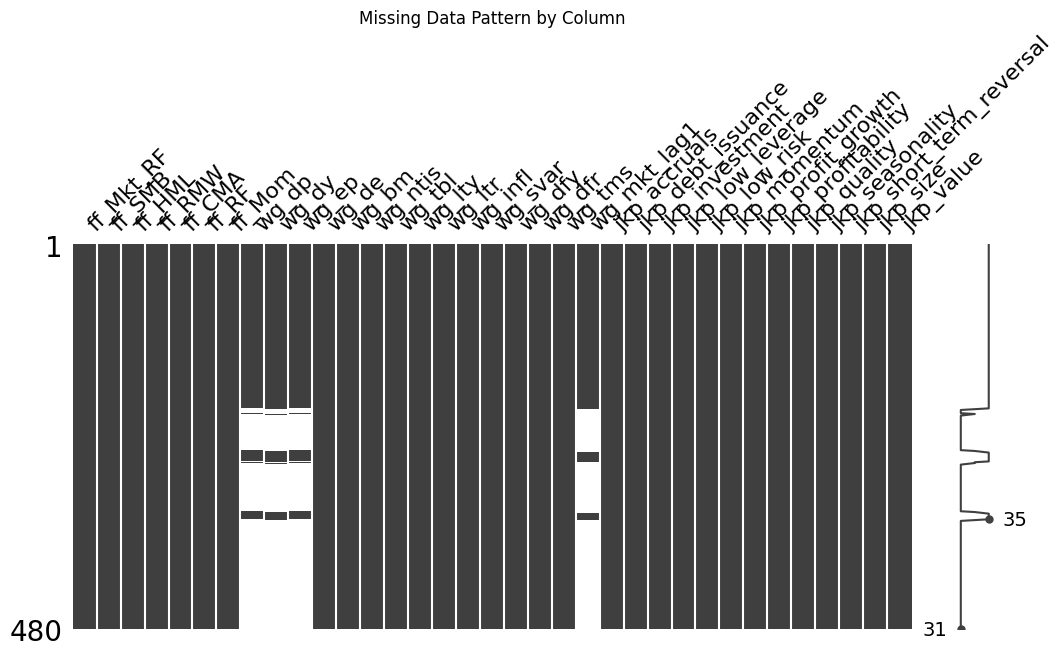

In [ ]:
# get missing data c

# Visualize missing data patterns
msno.matrix(merged_trunc, figsize=(12, 5))
plt.title("Missing Data Pattern by Column")
plt.show()

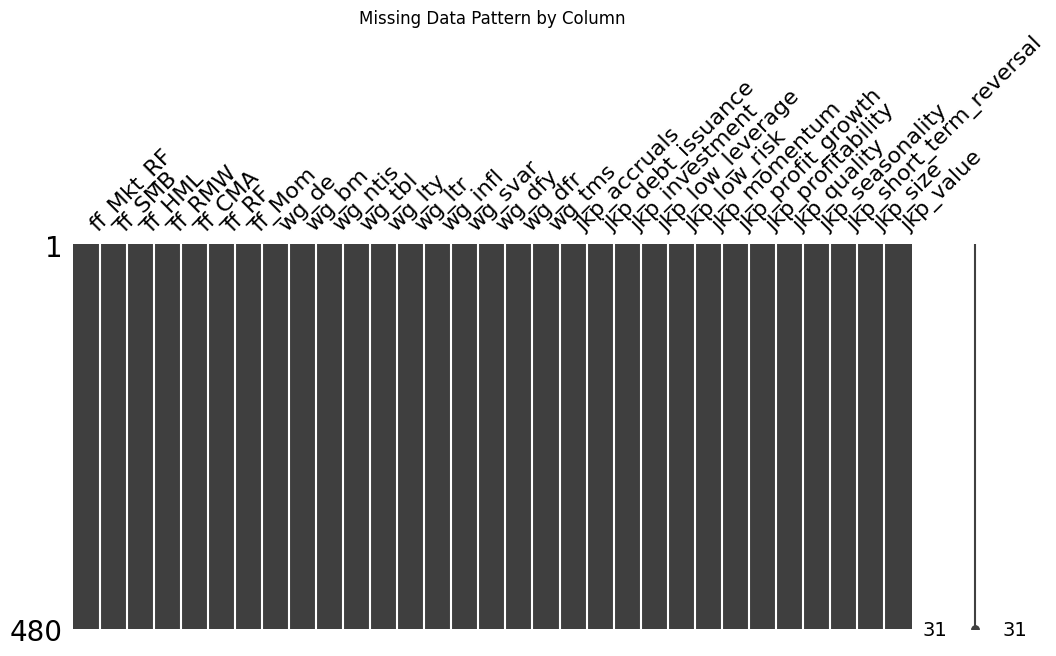

In [ ]:
#Lets get rid of the 4 predictso with a lot of nans
feats = [col for col in merged_trunc.columns if col not in ['wg_dp', 'wg_dy', 'wg_ep', 'wg_mkt_lag1']]


# get missing data c

# Visualize missing data patterns
msno.matrix(merged_trunc[feats], figsize=(12, 5))
plt.title("Missing Data Pattern by Column")
plt.show()

In [ ]:
# Lets work with just 31 features for now, we will extend to all the features later
df = merged_trunc[feats]

In [ ]:
df.head(-5)

,ff_Mkt_RF,ff_SMB,ff_HML,ff_RMW,ff_CMA,ff_RF,ff_Mom,wg_de,wg_bm,wg_ntis,...,jkp_low_leverage,jkp_low_risk,jkp_momentum,jkp_profit_growth,jkp_profitability,jkp_quality,jkp_seasonality,jkp_short_term_reversal,jkp_size,jkp_value
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,-0.0506,0.0330,0.0674,-0.0338,0.0427,0.0104,-0.0782,-0.866016,0.907239,0.028695,...,-0.019523,0.048566,-0.058776,-0.023648,-0.038931,-0.021366,0.000211,-0.009292,0.049486,0.054983
1981-02-01,0.0061,-0.0065,0.0097,0.0026,0.0206,0.0107,-0.0135,-0.854143,0.881816,0.030009,...,-0.004663,0.014236,-0.003338,-0.007910,-0.005200,0.003603,-0.002775,-0.009965,-0.004252,0.018210
1981-03-01,0.0366,0.0285,0.0061,-0.0227,-0.0056,0.0121,0.0082,-0.842281,0.924921,0.027939,...,-0.003233,0.000398,-0.015186,-0.006294,-0.011882,0.000108,0.005139,0.015530,0.013850,0.012002
1981-04-01,-0.0216,0.0472,0.0228,0.0081,0.0154,0.0108,-0.0108,-0.846234,0.930594,0.027352,...,0.005796,0.018726,0.010985,-0.005683,-0.003592,0.012281,0.000908,0.001136,0.032095,0.010561
1981-05-01,0.0013,0.0236,-0.0043,0.0047,-0.0178,0.0115,0.0356,-0.850149,0.936224,0.028845,...,0.009812,-0.012021,0.024549,0.007401,0.004527,0.004939,-0.001201,-0.017712,0.006182,-0.014697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,-0.1335,-0.0818,-0.1383,-0.0161,0.0119,0.0012,0.0821,-0.669101,0.306097,-0.007700,...,0.057200,0.064948,0.056106,0.019596,0.032428,0.061268,-0.023236,-0.002540,-0.056952,-0.085380
2020-04-01,0.1358,0.0257,-0.0134,0.0276,-0.0102,0.0000,-0.0548,-0.618286,0.275563,-0.010538,...,0.034473,-0.089420,-0.045639,-0.003612,-0.029667,0.003712,0.016294,0.030095,0.028638,-0.003624
2020-05-01,0.0559,0.0192,-0.0500,0.0096,-0.0316,0.0001,0.0016,-0.564814,0.264301,-0.014967,...,0.041227,-0.028549,0.025328,0.002350,-0.029066,0.018798,-0.000238,-0.003323,-0.013895,-0.061341


## IPCA explanation and strategy layout

In [46]:
df.head(-5)

,ff_Mkt_RF,ff_SMB,ff_HML,ff_RMW,ff_CMA,ff_RF,ff_Mom,wg_de,wg_bm,wg_ntis,...,jkp_low_leverage,jkp_low_risk,jkp_momentum,jkp_profit_growth,jkp_profitability,jkp_quality,jkp_seasonality,jkp_short_term_reversal,jkp_size,jkp_value
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,-0.0506,0.0330,0.0674,-0.0338,0.0427,0.0104,-0.0782,-0.866016,0.907239,0.028695,...,-0.019523,0.048566,-0.058776,-0.023648,-0.038931,-0.021366,0.000211,-0.009292,0.049486,0.054983
1981-02-01,0.0061,-0.0065,0.0097,0.0026,0.0206,0.0107,-0.0135,-0.854143,0.881816,0.030009,...,-0.004663,0.014236,-0.003338,-0.007910,-0.005200,0.003603,-0.002775,-0.009965,-0.004252,0.018210
1981-03-01,0.0366,0.0285,0.0061,-0.0227,-0.0056,0.0121,0.0082,-0.842281,0.924921,0.027939,...,-0.003233,0.000398,-0.015186,-0.006294,-0.011882,0.000108,0.005139,0.015530,0.013850,0.012002
1981-04-01,-0.0216,0.0472,0.0228,0.0081,0.0154,0.0108,-0.0108,-0.846234,0.930594,0.027352,...,0.005796,0.018726,0.010985,-0.005683,-0.003592,0.012281,0.000908,0.001136,0.032095,0.010561
1981-05-01,0.0013,0.0236,-0.0043,0.0047,-0.0178,0.0115,0.0356,-0.850149,0.936224,0.028845,...,0.009812,-0.012021,0.024549,0.007401,0.004527,0.004939,-0.001201,-0.017712,0.006182,-0.014697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,-0.1335,-0.0818,-0.1383,-0.0161,0.0119,0.0012,0.0821,-0.669101,0.306097,-0.007700,...,0.057200,0.064948,0.056106,0.019596,0.032428,0.061268,-0.023236,-0.002540,-0.056952,-0.085380
2020-04-01,0.1358,0.0257,-0.0134,0.0276,-0.0102,0.0000,-0.0548,-0.618286,0.275563,-0.010538,...,0.034473,-0.089420,-0.045639,-0.003612,-0.029667,0.003712,0.016294,0.030095,0.028638,-0.003624
2020-05-01,0.0559,0.0192,-0.0500,0.0096,-0.0316,0.0001,0.0016,-0.564814,0.264301,-0.014967,...,0.041227,-0.028549,0.025328,0.002350,-0.029066,0.018798,-0.000238,-0.003323,-0.013895,-0.061341


In [47]:
df.columns

Index(['ff_Mkt_RF', 'ff_SMB', 'ff_HML', 'ff_RMW', 'ff_CMA', 'ff_RF', 'ff_Mom',
       'wg_de', 'wg_bm', 'wg_ntis', 'wg_tbl', 'wg_lty', 'wg_ltr', 'wg_infl',
       'wg_svar', 'wg_dfy', 'wg_dfr', 'wg_tms', 'jkp_accruals',
       'jkp_debt_issuance', 'jkp_investment', 'jkp_low_leverage',
       'jkp_low_risk', 'jkp_momentum', 'jkp_profit_growth',
       'jkp_profitability', 'jkp_quality', 'jkp_seasonality',
       'jkp_short_term_reversal', 'jkp_size', 'jkp_value'],
      dtype='str')

In [48]:
# We want to predic tthe excess return of the market factor, using the Grasmanninan approach in 'IPCA_Gass_estimation.py' in src/pycache, lest create charateristics(Zt) for all of the features, and then we will use the IPCA approach to predict the excess return of the market factor.
def create_characteristics(df):
    # Create lagged momentum and vol features for each factor
    for col in df.columns:
        df[f'{col}_lag2_12'] = df[col].shift(2).rolling(11).mean()
        # create volatility features
        df[f'{col}_vol_12'] = df[col].shift(1).rolling(12).std
        # create other charactere


### Build inputs to be able to use IPCA_Grass_estimator

In [49]:


def build_ipca_inputs(
    df: pd.DataFrame,
    factor_prefix: str = "jkp_",
    macro_prefixes: tuple = ("wg_", "ff_"),
    include_intercept: bool = True,
    clip_signals: float = 5.0,
    impute: str = "zero",   # "zero" or "drop"
):
    """
    Build data = [rets, Z] for GrassmannManifoldIPCAEstimator.
    rets: (T, N)  where N = number of equity factors (assets)
    Z:    (T, N, m)
    """

    # 1) Equity factors as cross-section "assets"
    R = df[[c for c in df.columns if c.startswith(factor_prefix)]].copy()
    R = R.sort_index()

    # 2) Per-factor lagged characteristics (no look-ahead)
    lag1 = R.shift(1)
    mom_2_12 = R.shift(2).rolling(11).mean()
    vol_12 = R.shift(1).rolling(12).std()  # fixed: std()

    # Time-series standardization (asset-by-asset)
    def _std_ts(X):
        s = X.expanding(min_periods=37).std()
        return (X / s.shift(1)).clip(-clip_signals, clip_signals)

    lag1_s = _std_ts(lag1)
    mom_s = _std_ts(mom_2_12)
    vol_s = _std_ts(vol_12)

    # 3) Optional macro predictors, replicated across assets at each t
    macro_cols = [c for c in df.columns if any(c.startswith(p) for p in macro_prefixes)]
    M = df[macro_cols].copy().sort_index() if macro_cols else pd.DataFrame(index=R.index)
    M = M.shift(1)  # ensure no look-ahead
    M_s = _std_ts(M) if not M.empty else M
    

    # 4) Build aligned panel
    # Target returns are contemporaneous R_t; predictors are lagged by construction above.
    aligned = pd.concat([R, lag1_s, mom_s, vol_s, M_s], axis=1)

    if impute == "drop":
        aligned = aligned.dropna()
        R = aligned[R.columns]
        lag1_s = aligned[lag1_s.columns]
        mom_s = aligned[mom_s.columns]
        vol_s = aligned[vol_s.columns]
        M_s = aligned[M_s.columns] if not M_s.empty else M_s
    elif impute == "zero":
        R = R.fillna(0.0)
        lag1_s = lag1_s.fillna(0.0)
        mom_s = mom_s.fillna(0.0)
        vol_s = vol_s.fillna(0.0)
        if not M_s.empty:
            M_s = M_s.fillna(0.0)
    else:
        raise ValueError("impute must be 'zero' or 'drop'")

    # 5) Tensor assembly
    T, N = R.shape
    chars = []

    if include_intercept:
        chars.append(np.ones((T, N), dtype=float))  # (T,N,1)

    chars.extend([
        lag1_s.to_numpy(dtype=float),
        mom_s.to_numpy(dtype=float),
        vol_s.to_numpy(dtype=float),
    ])

    if not M_s.empty:
        M_np = M_s.to_numpy(dtype=float)  # (T, q)
        for j in range(M_np.shape[1]):
            chars.append(np.repeat(M_np[:, [j]], N, axis=1))  # (T,N)

    Z = np.stack(chars, axis=2)                 # (T, N, m)
    rets = R.to_numpy(dtype=float)              # (T, N)

    meta = {
        "dates": R.index,
        "asset_names": list(R.columns),
        "num_assets": N,
        "num_char": Z.shape[2],
        "num_periods": T,
    }
    return [rets, Z], meta


# Example usage
data_ipca, meta = build_ipca_inputs(
    merged_trunc,
    factor_prefix="jkp_",
    macro_prefixes=("wg_", "ff_"),
    include_intercept=True,
    impute="zero",
)

rets, Z = data_ipca

print("rets shape:", rets.shape)  # (T, N)
print("Z shape   :", Z.shape)     # (T, N, m)
print(meta)

# ...existing code...


# Drop early burn-in periods to avoid unstable early expanding-standardization rows
burn_in = 48  # try 36/48/60
if burn_in >= rets.shape[0]:
    raise ValueError(f"burn_in={burn_in} is too large for T={rets.shape[0]}")

rets = rets[burn_in:, :]
Z = Z[burn_in:, :, :]

# keep metadata aligned
meta["dates"] = meta["dates"][burn_in:]
meta["num_periods"] = rets.shape[0]

print(f"After burn-in drop: rets={rets.shape}, Z={Z.shape}, T={meta['num_periods']}")
# ...existing code...

rets shape: (480, 13)
Z shape   : (480, 13, 26)
{'dates': DatetimeIndex(['1981-01-01', '1981-02-01', '1981-03-01', '1981-04-01',
               '1981-05-01', '1981-06-01', '1981-07-01', '1981-08-01',
               '1981-09-01', '1981-10-01',
               ...
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01',
               '2020-11-01', '2020-12-01'],
              dtype='datetime64[us]', name='date', length=480, freq=None), 'asset_names': ['jkp_accruals', 'jkp_debt_issuance', 'jkp_investment', 'jkp_low_leverage', 'jkp_low_risk', 'jkp_momentum', 'jkp_profit_growth', 'jkp_profitability', 'jkp_quality', 'jkp_seasonality', 'jkp_short_term_reversal', 'jkp_size', 'jkp_value'], 'num_assets': 13, 'num_char': 26, 'num_periods': 480}
After burn-in drop: rets=(432, 13), Z=(432, 13, 26), T=432


### Solve the IPCA/Grassman_manifold optimization problem

In [50]:
# ...existing code...

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.__pycache__.IPCA_Grass_estimator import GrassmannManifoldIPCAEstimator


num_assets = rets.shape[1]
num_fact = 2
num_charact = Z.shape[2]
win_len = rets.shape[0]

est = GrassmannManifoldIPCAEstimator(
    num_assets=num_assets,
    num_fact=num_fact,
    num_charact=num_charact,
    win_len=win_len,
)

Wopt, f_hat, history = est.fit(
    data=[rets, Z],
    optimizer="ConjugateGradient",
    max_iterations=200,
    verbosity=1,
    log_verbosity=1,
)

print("Wopt:", Wopt.shape)   # (m, k)
print("f_hat:", f_hat.shape) # (T, k)

# ...existing code...

Optimizing...
Terminated - max iterations reached after 71.42 seconds.

Wopt: (26, 2)
f_hat: (432, 2)


In [51]:
Wopt_df = pd.DataFrame(Wopt, columns=[f'Factor_{i+1}' for i in range(num_fact)])
Wopt_df['Characteristic'] = [f'Char_{j+1}' for j in range(num_charact)]
Wopt_df = Wopt_df.set_index('Characteristic')
print(Wopt_df)

                Factor_1  Factor_2
Characteristic                    
Char_1         -0.120198  0.132690
Char_2         -0.475529 -0.677554
Char_3          0.254381 -0.306512
Char_4         -0.013280  0.015452
Char_5          0.170204  0.045067
Char_6          0.170920 -0.010734
Char_7         -0.211208  0.001768
Char_8         -0.034364 -0.090967
Char_9          0.110476  0.061662
Char_10        -0.183033  0.107418
Char_11        -0.053600 -0.116705
Char_12         0.125261 -0.068833
Char_13         0.335208 -0.395175
Char_14        -0.042087 -0.127759
Char_15        -0.151946  0.041075
Char_16         0.109164 -0.294036
Char_17         0.415996 -0.004879
Char_18         0.165532  0.016381
Char_19        -0.244035  0.070071
Char_20         0.016865 -0.166262
Char_21        -0.094174  0.223495
Char_22        -0.230389  0.049896
Char_23         0.182335  0.027381
Char_24         0.012561 -0.093397
Char_25        -0.146491  0.063148
Char_26        -0.007373 -0.160085


In [52]:
f_hat_df = pd.DataFrame(f_hat, index=meta['dates'], columns=[f'Factor_{i+1}' for i in range(num_fact)])
print(f_hat_df.head())

            Factor_1  Factor_2
date                          
1985-01-01  0.002087 -0.000984
1985-02-01  0.000864  0.002190
1985-03-01 -0.010006 -0.010207
1985-04-01 -0.008397 -0.009004
1985-05-01 -0.004506 -0.005828


In [53]:
# lets split the factor returns into train and test, and see how well the factors do in-sample vs out-of-sample. We will use the first 80% of the data for training, and the remaining 20% for testing.
# ...existing code...

# Train/test split (time-ordered)
T = rets.shape[0]
split_idx = int(0.8 * T)

rets_train, rets_test = rets[:split_idx], rets[split_idx:]
Z_train, Z_test = Z[:split_idx], Z[split_idx:]
dates_train = meta["dates"][:split_idx]
dates_test = meta["dates"][split_idx:]

print(f"Train: rets={rets_train.shape}, Z={Z_train.shape}")
print(f"Test : rets={rets_test.shape}, Z={Z_test.shape}")

# Fit on TRAIN only
num_assets = rets_train.shape[1]
num_fact = 2
num_charact = Z_train.shape[2]
win_len = rets_train.shape[0]

est = GrassmannManifoldIPCAEstimator(
    num_assets=num_assets,
    num_fact=num_fact,
    num_charact=num_charact,
    win_len=win_len,
)

Wopt, f_hat_train, history = est.fit(
    data=[rets_train, Z_train],
    optimizer="ConjugateGradient",
    max_iterations=200,
    verbosity=1,
    log_verbosity=1,
)

print("Wopt:", Wopt.shape)               # (m, k)
print("f_hat_train:", f_hat_train.shape) # (T_train, k)

def infer_factors_given_W(rets_block, Z_block, W):
    T_block = rets_block.shape[0]
    k = W.shape[1]
    f_block = np.zeros((T_block, k), dtype=float)
    for t in range(T_block):
        Lambda_t = Z_block[t] @ W
        r_t = rets_block[t]
        f_t, *_ = np.linalg.lstsq(Lambda_t, r_t, rcond=None)
        f_block[t] = f_t
    return f_block

def reconstruct_returns(Z_block, f_block, W):
    T_block = Z_block.shape[0]
    N = Z_block.shape[1]
    rhat = np.zeros((T_block, N), dtype=float)
    for t in range(T_block):
        Lambda_t = Z_block[t] @ W
        rhat[t] = Lambda_t @ f_block[t]
    return rhat

# A) Contemporaneous test cross-sectional fit (uses test returns -> NOT forecast)
f_hat_test_cs = infer_factors_given_W(rets_test, Z_test, Wopt)
rhat_test_cs = reconstruct_returns(Z_test, f_hat_test_cs, Wopt)

mse_test_cs = np.mean((rets_test - rhat_test_cs) ** 2)
r2_test_cs = 1.0 - np.sum((rets_test - rhat_test_cs) ** 2) / np.sum((rets_test - rets_test.mean()) ** 2)

print(f"Test contemporaneous CS MSE (not forecast): {mse_test_cs:.6e}")
print(f"Test contemporaneous CS R^2 (not forecast): {r2_test_cs:.4f}")

# B) True OOS forecast (no rets_test used for factor inference)
# simple baseline: use mean train factor return each period
f_mean_train = f_hat_train.mean(axis=0, keepdims=True)                 # (1, k)
f_hat_test_pred = np.repeat(f_mean_train, rets_test.shape[0], axis=0)  # (T_test, k)
rhat_test_pred = reconstruct_returns(Z_test, f_hat_test_pred, Wopt)

mse_oos_forecast = np.mean((rets_test - rhat_test_pred) ** 2)
r2_oos_forecast = 1.0 - np.sum((rets_test - rhat_test_pred) ** 2) / np.sum((rets_test - rets_test.mean()) ** 2)

print(f"True OOS forecast MSE: {mse_oos_forecast:.6e}")
print(f"True OOS forecast R^2: {r2_oos_forecast:.4f}")

# Optional DataFrames
f_hat_train_df = pd.DataFrame(
    f_hat_train, index=dates_train, columns=[f"Factor_{i+1}" for i in range(num_fact)]
)
f_hat_test_cs_df = pd.DataFrame(
    f_hat_test_cs, index=dates_test, columns=[f"Factor_{i+1}" for i in range(num_fact)]
)

print("Train factor returns (estimated):")
print(f_hat_train_df.head())
print("Test factor returns (estimated contemporaneously; not forecast):")
print(f_hat_test_cs_df.head())

# ...existing code...

Train: rets=(345, 13), Z=(345, 13, 26)
Test : rets=(87, 13), Z=(87, 13, 26)
Optimizing...
Terminated - max iterations reached after 56.75 seconds.

Wopt: (26, 2)
f_hat_train: (345, 2)
Test contemporaneous CS MSE (not forecast): 2.002088e-04
Test contemporaneous CS R^2 (not forecast): 0.3009
True OOS forecast MSE: 2.859014e-04
True OOS forecast R^2: 0.0017
Train factor returns (estimated):
            Factor_1  Factor_2
date                          
1985-01-01 -0.034002  0.013102
1985-02-01  0.001830 -0.002773
1985-03-01  0.010562  0.069601
1985-04-01  0.001676  0.010654
1985-05-01  0.005610  0.000331
Test factor returns (estimated contemporaneously; not forecast):
            Factor_1  Factor_2
date                          
2013-10-01  0.000117 -0.021081
2013-11-01  0.021527 -0.002154
2013-12-01  0.006524 -0.007058
2014-01-01  0.017752  0.055443
2014-02-01  0.002068  0.005517


In [54]:
# ...existing code...

def forecast_next_factor(f_train, mode="mean"):
    # f_train: (T_train, k)
    if mode == "mean":
        return f_train.mean(axis=0)
    elif mode == "ar1":
        k = f_train.shape[1]
        out = np.zeros(k)
        for j in range(k):
            y = f_train[1:, j]
            x = f_train[:-1, j]
            X = np.column_stack([np.ones_like(x), x])
            b, *_ = np.linalg.lstsq(X, y, rcond=None)   # y = a + b*x
            out[j] = b[0] + b[1] * f_train[-1, j]
        return out
    else:
        raise ValueError("mode must be 'mean' or 'ar1'")

def walkforward_oos_panel(rets, Z, start_train=120, num_fact=2, factor_model="mean"):
    T, N = rets.shape
    preds = np.full((T, N), np.nan)

    for t in range(start_train, T):
        rets_tr, Z_tr = rets[:t], Z[:t]

        est = GrassmannManifoldIPCAEstimator(
            num_assets=N,
            num_fact=num_fact,
            num_charact=Z.shape[2],
            win_len=rets_tr.shape[0],
        )

        W_t, f_tr, _ = est.fit(
            data=[rets_tr, Z_tr],
            optimizer="ConjugateGradient",
            max_iterations=200,
            verbosity=0,
            log_verbosity=0,
        )

        f_next = forecast_next_factor(f_tr, mode=factor_model)      # uses train only
        Lambda_t = Z[t] @ W_t                                        # uses t characteristics only
        preds[t] = Lambda_t @ f_next                                 # predicts rets[t]

    valid = ~np.isnan(preds).any(axis=1)
    y_true = rets[valid]
    y_pred = preds[valid]

    mse = np.mean((y_true - y_pred) ** 2)

    # OOS R2 vs historical-mean benchmark (computed from training window only each t)
    bench = np.full_like(y_true, np.nan)
    valid_idx = np.where(valid)[0]
    for i, t in enumerate(valid_idx):
        bench[i] = rets[:t].mean(axis=0)

    sse_model = np.sum((y_true - y_pred) ** 2)
    sse_bench = np.sum((y_true - bench) ** 2)
    r2_oos = 1.0 - sse_model / sse_bench

    return preds, {"mse": mse, "r2_oos_vs_hist_mean": r2_oos, "n_oos_periods": valid.sum()}

# run
preds, stats = walkforward_oos_panel(rets, Z, start_train=120, num_fact=2, factor_model="ar1")
print(stats)

# ...existing code...

{'mse': np.float64(0.8828042323003343), 'r2_oos_vs_hist_mean': np.float64(-1152.6177976102565), 'n_oos_periods': np.int64(312)}


# Working with stock level return + characteristics prediction

## Analysis with a subset of things

In [5]:
#These charactereistics dont have much variance in them, making the problem illposed, lets load the return data for these stock from 2020 - 2026 and create our our characteristics using the return data, and then we will use the IPCA approach to predict the return of stocks. We will perform the same for a bigger period later

df_returns = pd.read_excel("df_data_all_stocks_2020_onwards.xlsx")
df_returns.rename(columns={'yyyymm': 'date'}, inplace=True)
df_returns.head()
# lets pivot the table to have permno and date as index, and all the columns as values, and then we will use this data to create our characteristics for the IPCA approach. We will use the return data to create momentum and volatility characteristics for each stock, and then we will use these characteristics to predict the return of stocks using the IPCA approach.

df_returns = df_returns.pivot_table(index=['permno', 'date'], values=[col for col in df_returns.columns if col not in ['permno', 'date']], aggfunc='first')
df_returns.head()

#lets see how the data looks like for a few more columns, thigs arebeing truncated in.head()

# we need to see more columns i.e, horizontal view
with pd.option_context("display.max_columns", None, "display.width", 50, "display.max_colwidth", None):
    print(df_returns.loc[10104].head(10).to_string())

                  AM  AOP  AbnormalAccruals  Accruals  AccrualsBM     AdExp  AnalystRevision  AnalystValue  AnnouncementReturn  AssetGrowth  BM     BMdec     BPEBM      Beta    BetaFP  BetaLiquidityPS  BetaTailRisk  BidAskSpread  BookLeverage  BrandInvest  CBOperProf        CF  CPVolSpread      Cash  CashProd  ChAssetTurnover      ChEQ  ChForecastAccrual     ChInv   ChInvIA  ChNAnalyst   ChNNCOA     ChNWC     ChTax  ChangeInRecommendation  CitationsRD  CompEquIss  CompositeDebtIssuance  ConsRecomm  ConvDebt  CoskewACX  Coskewness  CredRatDG  CustomerMomentum  DebtIssuance  DelBreadth    DelCOA    DelCOL    DelDRC    DelEqu   DelFINL  DelLTI  DelNetFin  DivInit  DivOmit  DivSeason  DivYieldST     DolVol  DownRecomm       EBM        EP  EarnSupBig  EarningsConsistency  EarningsForecastDisparity  EarningsStreak  EarningsSurprise    EntMult  EquityDuration  ExchSwitch  ExclExp  FEPS  FR  FirmAge  ForecastDispersion  Frontier       GP   GrAdExp   GrLTNOA  GrSaleToGrInv  GrSaleToGrOverhead  

In [6]:
#chars restructuring

char_feats = [ 'Beta', 'skew1',  'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD']
# lets work with just these 4 features for now, we will extend to all the features later
df_trunc = df_returns[char_feats + ['Price']]
#create a return column from the price, shift the returns by 1 so that there is no look ahead

df_trunc['ret'] = df_trunc.groupby(level=0)['Price'].pct_change()
df_trunc['ret'] = df_trunc['ret'].shift(-1)
df_trunc.dropna(inplace=True)
df_trunc.head()

#lets run the same as above but with window_len = 24, and include more characteristics, and see how the performance changes with the window length and the number of characteristics. We will try with 1, 2, 3, 4, 5 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
char_feats_extended = ['Beta', 'skew1', 'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD', 'Mom12m', 'Mom1m', 'Vol1m']
window_len = 24

 # dont truncate while printing columns, we want to see all the columns to decide which ones to include as characteristics
print(df_returns.columns.tolist()) # print columns as list for better readability
# lets pick 50 characteristics with least missing data, and not mostly constant values, and then we will use these characteristics to run the IPCA_Grass_estimation and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# Diagnose missing/zeros for all columns
nan_frac = df_returns.isna().mean()
zero_frac = (df_returns == 0).mean()
# Filter columns with low missing/zero fractions
good_cols = (nan_frac <= 0.3) & (zero_frac <= 0.3)
good_cols = good_cols[good_cols].index.tolist()
print(f"Number of good columns: {len(good_cols)}")
print("Good columns:", good_cols)
# We will exclude the 'Price' column and the 'ret' column from the characteristics, and we will also exclude the columns that are not in the good_cols list, and then we will
# run the IPCA_Grass_estimation with the remaining columns as characteristics, and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
excluded_cols = ['Price', 'ret']
char_feats_final = [col for col in good_cols if col not in excluded_cols]
print(f"Number of characteristics used: {len(char_feats_final)}")
print("Characteristics used:", char_feats_final)
# create a df to pass to the function
df_trunc_extended = df_returns[char_feats_final + ['Price']]
# create return column
df_trunc_extended['ret'] = df_trunc_extended.groupby(level=0)['Price'].pct_change()
df_trunc_extended['ret'] = df_trunc_extended['ret'].shift(-1)
df_trunc_extended.dropna(inplace=True)

# lets drop 1/3 of the char_feats_final as we get ipplosed problems now
char_feats_reduced = char_feats_final[-33:]
print(f"Number of characteristics used after reduction: {len(char_feats_reduced)}")
print("Characteristics used after reduction:", char_feats_reduced)

['AM', 'AOP', 'AbnormalAccruals', 'Accruals', 'AccrualsBM', 'AdExp', 'AnalystRevision', 'AnalystValue', 'AnnouncementReturn', 'AssetGrowth', 'BM', 'BMdec', 'BPEBM', 'Beta', 'BetaFP', 'BetaLiquidityPS', 'BetaTailRisk', 'BidAskSpread', 'BookLeverage', 'BrandInvest', 'CBOperProf', 'CF', 'CPVolSpread', 'Cash', 'CashProd', 'ChAssetTurnover', 'ChEQ', 'ChForecastAccrual', 'ChInv', 'ChInvIA', 'ChNAnalyst', 'ChNNCOA', 'ChNWC', 'ChTax', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'ConvDebt', 'CoskewACX', 'Coskewness', 'CredRatDG', 'CustomerMomentum', 'DebtIssuance', 'DelBreadth', 'DelCOA', 'DelCOL', 'DelDRC', 'DelEqu', 'DelFINL', 'DelLTI', 'DelNetFin', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'DolVol', 'DownRecomm', 'EBM', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'EquityDuration', 'ExchSwitch', 'ExclExp', 'FEPS', 'FR', 'FirmAge', 'ForecastDispersion', 'Frontie

/var/folders/js/pgf30x597b53rt2mghx7jpmm0000gn/T/ipykernel_61629/4015258378.py:8: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_trunc['ret'] = df_trunc.groupby(level=0)['Price'].pct_change()
/var/folders/js/pgf30x597b53rt2mghx7jpmm0000gn/T/ipykernel_61629/4015258378.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trunc['ret'] = df_trunc.groupby(level=0)['Price'].pct_change()
/var/folders/js/pgf30x597b53rt2mghx7jpmm0000gn/T/ipykernel_61629/4015258378.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

### Some super preliminary runs

Number of characteristics used after reduction: 33
Characteristics used after reduction: ['MaxRet', 'MeanRankRevGrowth', 'Mom12mOffSeason', 'MomOffSeason', 'MomOffSeason06YrPlus', 'NOA', 'NetDebtFinance', 'NetEquityFinance', 'OPLeverage', 'PctAcc', 'PctTotAcc', 'RDS', 'RealizedVol', 'ResidualMomentum', 'ReturnSkew', 'ReturnSkew3F', 'RoE', 'STreversal', 'ShareRepurchase', 'Size', 'Tax', 'TotalAccruals', 'VolMkt', 'VolSD', 'VolumeTrend', 'XFIN', 'betaVIX', 'dNoa', 'hire', 'year', 'zerotrade12M', 'zerotrade1M', 'zerotrade6M']

Num factors: 1, Run 1/3
OOS MSE: 6.666218e-01
OOS R2 : -1171.4043
Market-timing Sharpe (annualized): 0.703

Num factors: 1, Run 2/3
OOS MSE: 4.889270e+00
OOS R2 : -8597.8808
Market-timing Sharpe (annualized): 0.609

Num factors: 1, Run 3/3
OOS MSE: 8.144384e+00
OOS R2 : -14322.7303
Market-timing Sharpe (annualized): 0.348

Num factors: 1, Average OOS R2: -8030.6718, Average Sharpe: 0.553

Num factors: 2, Run 1/3
OOS MSE: 1.314113e-01
OOS R2 : -230.1163
Market-timing

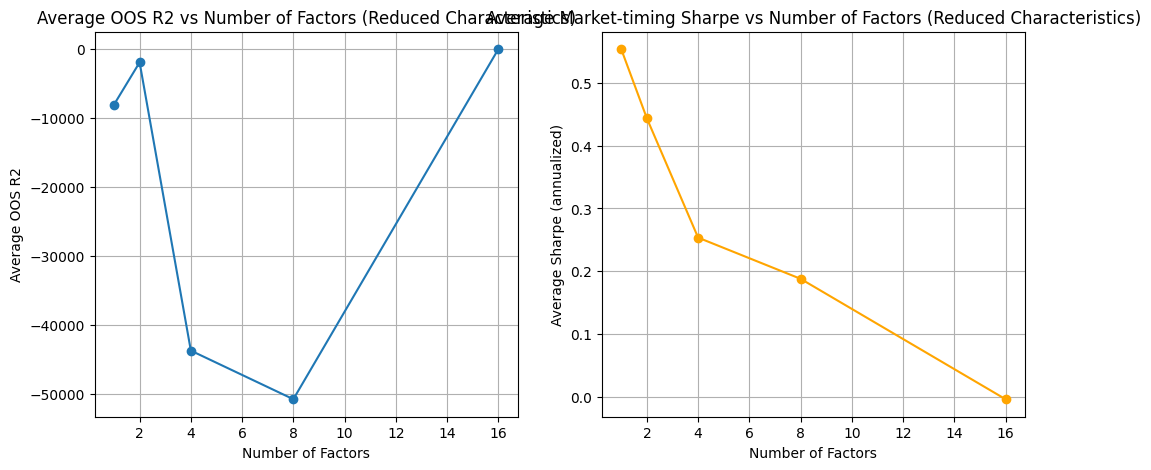

In [ ]:

# run the IPCA_Grass_estimation with the reduced characteristics list, and see how the performance changes with the number of factors and the window length. We will try with 2,
# 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
num_factors_list = [1, 2, 4, 8, 16]
num_iter = 30    
results_by_factor = {}
for num_fact in num_factors_list:
    # we iterate num_iter times for each num_fact to get an average performance
    all_results = []
    for i in range(num_iter):
        print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
        res = run_ipca_grass(
            df_trunc=df_trunc_extended,
            char_feats=char_feats_reduced,
            num_fact=num_fact,
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)
    avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
    avg_sharpe = np.mean([res["sharpe"] for res in all_results])
    results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
    print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# Lets plot the results
num_factors = list(results_by_factor.keys())
avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(num_factors, avg_r2_oos_values, marker='o')
plt.title("Average OOS R2 vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average OOS R2")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
plt.title("Average Market-timing Sharpe vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average Sharpe (annualized)")
plt.grid()



Num factors: 1, Run 1/30
OOS MSE: 3.787039e+00
OOS R2 : -6659.3603
Market-timing Sharpe (annualized): 0.145

Num factors: 1, Run 2/30
OOS MSE: 1.905960e+01
OOS R2 : -33519.5859
Market-timing Sharpe (annualized): 0.372

Num factors: 1, Run 3/30
OOS MSE: 6.369497e-01
OOS R2 : -1119.2192
Market-timing Sharpe (annualized): 1.153

Num factors: 1, Run 4/30
OOS MSE: 3.502775e+00
OOS R2 : -6159.4182
Market-timing Sharpe (annualized): 0.840

Num factors: 1, Run 5/30
OOS MSE: 1.392035e+02
OOS R2 : -244819.6566
Market-timing Sharpe (annualized): 0.249

Num factors: 1, Run 6/30
OOS MSE: 1.405416e+01
OOS R2 : -24716.4049
Market-timing Sharpe (annualized): 1.301

Num factors: 1, Run 7/30
OOS MSE: 3.682491e-01
OOS R2 : -646.6488
Market-timing Sharpe (annualized): 0.502

Num factors: 1, Run 8/30
OOS MSE: 1.743873e+00
OOS R2 : -3065.9930
Market-timing Sharpe (annualized): 0.657

Num factors: 1, Run 9/30
OOS MSE: 7.083813e-01
OOS R2 : -1244.8477
Market-timing Sharpe (annualized): 0.623

Num factors: 1,

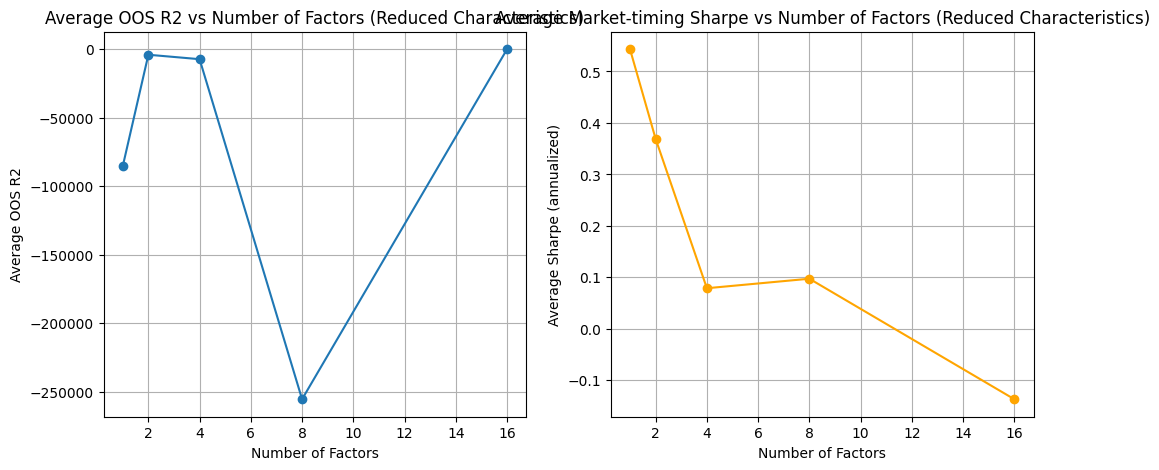

In [189]:
# Num iter 30 case for better confidence in the results, as there is some randomness in the IPCA estimation due to the optimization process, and we want to ensure that our results are not just a lucky run. We will try with 1, 2, 4, 8, 16 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
num_iter = 30    
results_by_factor = {}
for num_fact in num_factors_list:
    # we iterate num_iter times for each num_fact to get an average performance
    all_results = []
    for i in range(num_iter):
        print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
        res = run_ipca_grass(
            df_trunc=df_trunc_extended,
            char_feats=char_feats_reduced,
            num_fact=num_fact,
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)
    avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
    avg_sharpe = np.mean([res["sharpe"] for res in all_results])
    results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
    print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# Lets plot the results
num_factors = list(results_by_factor.keys())
avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(num_factors, avg_r2_oos_values, marker='o')
plt.title("Average OOS R2 vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average OOS R2")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
plt.title("Average Market-timing Sharpe vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average Sharpe (annualized)")
plt.grid()


### Things to clear up - when the sharpe seems to be so volatile, which return subspace structure do we examine to analyze the geometry

#### Things to note during run, char_feat can be high dimensinal but some chars can make the problem illposed, better to understand when and how this happens to avoid this during RFF runs

## Updated GrassManOpt to include stability metrics

### Runs with only few stability params

In [11]:
def run_ipca_grass_v2(
    df_trunc,
    char_feats,
    num_fact=2,
    window_len=12,
    max_nan=0.3,
    max_zero=0.3,
    min_non_nan_frac=0.7,
):
    # Build stock-level panel from df_trunc
    df_panel = df_trunc.copy().sort_index()

    # Returns panel (T, N)
    rets_panel = df_panel["ret"].unstack("permno").sort_index()

    # Lagged characteristics panels (T, N) for each feature
    X_list = []
    for col in char_feats:
        x = df_panel[col].unstack("permno").sort_index()
        x = x.shift(1)
        X_list.append(x)

    # Align assets across all panels
    common_assets = rets_panel.columns
    for x in X_list:
        common_assets = common_assets.intersection(x.columns)

    rets_panel = rets_panel[common_assets]
    X_list = [x[common_assets] for x in X_list]

    # Drop assets with too many missing/zeros in returns or any characteristic
    zero_frac_rets = (rets_panel == 0).mean()
    nan_frac_rets  = rets_panel.isna().mean()

    good_assets = (nan_frac_rets <= max_nan) & (zero_frac_rets <= max_zero)
    for x in X_list:
        good_assets &= (x.isna().mean() <= max_nan)
        good_assets &= ((x == 0).mean() <= max_zero)

    rets_panel = rets_panel.loc[:, good_assets]
    X_list = [x.loc[:, good_assets] for x in X_list]

    # Drop early rows with heavy NaNs (burn-in)
    min_non_nan = int(min_non_nan_frac * rets_panel.shape[1])
    valid_time = rets_panel.notna().sum(axis=1) >= min_non_nan
    for x in X_list:
        valid_time &= (x.notna().sum(axis=1) >= min_non_nan)

    rets_panel = rets_panel.loc[valid_time]
    X_list = [x.loc[valid_time] for x in X_list]

    # Impute remaining NaNs with cross-sectional mean
    rets_panel = rets_panel.apply(lambda s: s.fillna(s.mean()), axis=1)
    X_list = [x.apply(lambda s: s.fillna(s.mean()), axis=1) for x in X_list]

    # Standardize characteristics cross-sectionally
    X_list = [(x.sub(x.mean(axis=1), axis=0)).div(x.std(axis=1).replace(0, np.nan), axis=0) for x in X_list]
    X_list = [x.fillna(0.0) for x in X_list]

    # Stack into Z: (T, N, m)
    Z = np.stack([x.to_numpy(dtype=float) for x in X_list], axis=2)
    rets_stock = rets_panel.to_numpy(dtype=float)

    T, N = rets_stock.shape
    preds_stock = np.full_like(rets_stock, np.nan, dtype=float)

    # ── Accumulators for paper diagnostics ────────────────────────────────────
    W_prev          = None   # W from previous window, for subspace stability
    stability_dists = []     # d_proj(V_t, V_{t-1}) per window  (Section 4.2)
    erank_series    = []     # erank(Σ̂_f) per window            (Section 4.1)
    # ─────────────────────────────────────────────────────────────────────────

    for t in range(window_len, T):
        rets_tr = rets_stock[t - window_len:t]
        Z_tr    = Z[t - window_len:t]

        est = GrassmannManifoldIPCAEstimator(
            num_assets=N,
            num_fact=num_fact,
            num_charact=Z.shape[2],
            win_len=rets_tr.shape[0],
        )

        W_t, f_tr, _ = est.fit(
            data=[rets_tr, Z_tr],
            optimizer="ConjugateGradient",
            max_iterations=200,
            verbosity=0,
            log_verbosity=0,
        )

        # ── Metric 1: Subspace stability  (Section 4.2) ───────────────────────
        # d_proj(V_t, V_{t-1}) = ‖W_t W_tᵀ − W_prev W_prevᵀ‖_F
        # W_t has orthonormal columns (lives on Grassmann), so P = W Wᵀ directly.
        # Small value → stable subspace → virtuous complexity.
        # Large value → subspace rotating under sampling → illusory complexity.
        if W_prev is not None:
            P_curr = W_t   @ W_t.T    # (m, m) projection onto current subspace
            P_prev = W_prev @ W_prev.T # (m, m) projection onto previous subspace
            d_proj = np.linalg.norm(P_curr - P_prev, "fro")
            stability_dists.append(d_proj)
        W_prev = W_t
        # ─────────────────────────────────────────────────────────────────────

        # ── Metric 2: Effective rank of fitted factor covariance  (Section 4.1)
        # Σ̂_f = (1/T) Σ_t f̂_t f̂_tᵀ
        # erank(Σ̂_f) = exp(H(p)),  p_i = λ_i / tr(Σ̂_f)  (Shannon entropy)
        # erank ≪ k  → only a few factors active, rest fitting noise.
        # erank → k  → all k factors genuinely identified.
        Sigma_f = (f_tr.T @ f_tr) / f_tr.shape[0]          # (k, k)
        eigvals  = np.linalg.eigvalsh(Sigma_f)               # ascending
        eigvals  = np.maximum(eigvals, 0.0)                  # clip numerical noise
        total    = eigvals.sum()
        if total > 0:
            p        = eigvals / total
            p        = p[p > 0]                              # avoid log(0)
            erank    = np.exp(-np.sum(p * np.log(p)))        # exp(H(p))
        else:
            erank = 1.0
        erank_series.append(erank)
        # ─────────────────────────────────────────────────────────────────────

        # Forecast next factor as historical mean in window
        f_next = f_tr.mean(axis=0)
        Lambda_t = Z[t] @ W_t
        preds_stock[t] = Lambda_t @ f_next

    # ── Evaluate performance on valid rows ────────────────────────────────────
    valid  = ~np.isnan(preds_stock).any(axis=1)
    y_true = rets_stock[valid]
    y_pred = preds_stock[valid]

    mse_oos = np.mean((y_true - y_pred) ** 2)
    r2_oos  = 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    # Market-timing Sharpe (annualized for monthly data)
    pos      = y_pred / (np.mean(np.abs(y_pred), axis=1, keepdims=True) + 1e-12)
    port_ret = np.mean(pos * y_true, axis=1)
    sharpe   = np.mean(port_ret) / (np.std(port_ret, ddof=1) + 1e-12) * np.sqrt(12)

    # ── Aggregate paper diagnostics ───────────────────────────────────────────
    # Mean subspace stability: lower is better (stable factor space)
    mean_stability = float(np.mean(stability_dists)) if stability_dists else np.nan

    # Mean effective rank: higher → more genuinely active factors
    mean_erank     = float(np.mean(erank_series))   if erank_series     else np.nan

    # Fraction of windows where effective rank collapsed below 50% of nominal k
    # Flags windows where the optimizer wandered into the noise eigenspace
    erank_collapse_frac = float(np.mean(np.array(erank_series) < 0.5 * num_fact)) \
                          if erank_series else np.nan
    # ─────────────────────────────────────────────────────────────────────────

    print(f"OOS MSE                          : {mse_oos:.6e}")
    print(f"OOS R2                           : {r2_oos:.4f}")
    print(f"Market-timing Sharpe (annualized): {sharpe:.3f}")
    print(f"Mean subspace stability d_proj   : {mean_stability:.4f}  (lower = more stable)")
    print(f"Mean effective rank erank(Σ̂_f)  : {mean_erank:.4f}  (max = {num_fact})")
    print(f"Effective rank collapse fraction : {erank_collapse_frac:.4f}  (fraction of windows erank < k/2)")

    return {
        "r2_oos":               r2_oos,
        "sharpe":               sharpe,
        # ── paper diagnostics ──────────────────────────────────────────────
        "mean_subspace_stability": mean_stability,      # Section 4.2: d_proj series mean
        "stability_dist_series":   stability_dists,     # full per-window series
        "mean_erank":              mean_erank,          # Section 4.1: erank(Σ̂_f) mean
        "erank_series":            erank_series,        # full per-window series
        "erank_collapse_frac":     erank_collapse_frac, # fraction of windows erank < k/2
    }


Running for N_FEATURES: 6
Run 1/5 for N_FEATURES: 6
OOS MSE                          : 7.596351e-02
OOS R2                           : -0.0046
Market-timing Sharpe (annualized): 0.347
Mean subspace stability d_proj   : 0.7145  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 2.7359  (max = 4)
Effective rank collapse fraction : 0.0652  (fraction of windows erank < k/2)
Run 2/5 for N_FEATURES: 6
OOS MSE                          : 7.596651e-02
OOS R2                           : -0.0047
Market-timing Sharpe (annualized): 0.350
Mean subspace stability d_proj   : 0.7438  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 2.7301  (max = 4)
Effective rank collapse fraction : 0.0870  (fraction of windows erank < k/2)
Run 3/5 for N_FEATURES: 6
OOS MSE                          : 7.597057e-02
OOS R2                           : -0.0047
Market-timing Sharpe (annualized): 0.342
Mean subspace stability d_proj   : 0.7325  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 2.7272  (

,avg_r2_oos,avg_sharpe,avg_subspace_stability,avg_erank,avg_erank_collapse
6,-0.004655,0.346027,0.747698,2.730208,0.086957
12,-0.146259,-0.032783,1.352565,2.008154,0.491304
24,-3.979759,-0.310665,2.257520,2.093105,0.447826


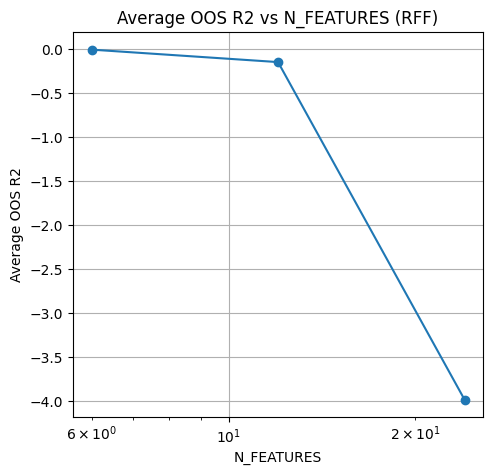

In [200]:
GAMMA = 0.2
N_FEATURES_EFF = [6, 12, 24]
df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
num_iter_rff = 5
results_by_factor_rff = {} 
#lets runf or different N_FEATURES_EFF values and store the results in a dictionary, but num_factors is always 4
for n_feat in N_FEATURES_EFF:
    print(f"\nRunning for N_FEATURES: {n_feat}")
    rff = RandomFourierFeatures(n_features=int(n_feat / 2), gamma=GAMMA)
    rff_data = rff.transform(X_chars, seed=1)
    rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
    rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns=rff_cols)
    df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
    
    all_results = []
    for i in range(num_iter_rff):
        print(f"Run {i+1}/{num_iter_rff} for N_FEATURES: {n_feat}")
        res = run_ipca_grass_v2(
            df_trunc=df_trunc_rff,
            char_feats=rff_cols,
            num_fact=4,  # keeping num_factors fixed at 4
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)
    results_by_factor_rff[n_feat] = {
        "avg_r2_oos": np.mean([res["r2_oos"] for res in all_results]),
        "avg_sharpe": np.mean([res["sharpe"] for res in all_results]),
        # ── paper diagnostics ──────────────────────────────────────────────
        "avg_subspace_stability": np.mean([res["mean_subspace_stability"] for res in all_results]),
        "avg_erank":             np.mean([res["mean_erank"] for res in all_results]),
        "avg_erank_collapse":    np.mean([res["erank_collapse_frac"] for res in all_results]),
    }
results_rff_df = pd.DataFrame(results_by_factor_rff).T
display(results_rff_df)
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(results_rff_df.index, results_rff_df["avg_r2_oos"], marker="o")
plt.title("Average OOS R2 vs N_FEATURES (RFF)")
plt.xlabel("N_FEATURES")
plt.ylabel("Average OOS R2")
plt.xscale("log")
plt.grid()


Running for N_FEATURES: 16
Run 1/3 for N_FEATURES: 16
OOS MSE                          : 9.094695e-02
OOS R2                           : -0.0441
Market-timing Sharpe (annualized): 0.576
Mean subspace stability d_proj   : 1.7610  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.7002  (max = 4)
Effective rank collapse fraction : 0.8824  (fraction of windows erank < k/2)
Run 2/3 for N_FEATURES: 16
OOS MSE                          : 9.404076e-02
OOS R2                           : -0.0796
Market-timing Sharpe (annualized): 0.994
Mean subspace stability d_proj   : 1.6946  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.8197  (max = 4)
Effective rank collapse fraction : 0.7941  (fraction of windows erank < k/2)
Run 3/3 for N_FEATURES: 16
OOS MSE                          : 8.853366e-02
OOS R2                           : -0.0164
Market-timing Sharpe (annualized): 0.599
Mean subspace stability d_proj   : 1.8351  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.814

,avg_r2_oos,avg_sharpe
16,-0.046716,0.722844
256,0.018468,0.454152
1024,-0.007902,0.633871
4096,0.024345,0.574316
16384,0.002410,0.099945


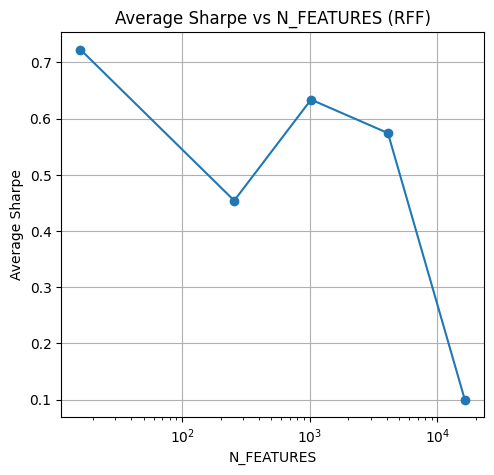

In [ ]:
## Same run as 2 cells above, but runnign with grassman_v2, for subspace stability and effective rank diagnostics, 

#lets create rff transformations of the characteristics and then run the IPCA_Grass_estimation with the rff transformed characteristics, and see how the performance changes with the number of factors and the window length. 

GAMMA = 0.2
N_FEATURES = 64

# RFF transform needs a dense numeric matrix
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1

# Impute missing values cross-sectionally by date, then columnwise fallback
X_chars = X_chars.groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
X_chars = X_chars.fillna(X_chars.median()).fillna(0.0)

GAMMA = 0.2
window_len = 24
N_FEATURES_EFF = [16, 256, 1024, 4096, 16384,]
rff = RandomFourierFeatures(n_features=int(N_FEATURES / 2), gamma=GAMMA)
rff_data = rff.transform(X_chars, seed=1)
rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns =rff_cols)
df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
num_iter_rff = 3
results_by_factor_rff = {} 
#lets runf or different N_FEATURES_EFF values and store the results in a dictionary, but num_factors is always 4
for n_feat in N_FEATURES_EFF:
    print(f"\nRunning for N_FEATURES: {n_feat}")
    rff = RandomFourierFeatures(n_features=int(n_feat / 2), gamma=GAMMA)
    rff_data = rff.transform(X_chars, seed=1)
    rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
    rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns=rff_cols)
    df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
    
    all_results = []
    for i in range(num_iter_rff):
        print(f"Run {i+1}/{num_iter_rff} for N_FEATURES: {n_feat}")
        res = run_ipca_grass_v2(
            df_trunc=df_trunc_rff,
            char_feats=rff_cols,
            num_fact=4,  # keeping num_factors fixed at 4
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)

    results_by_factor_rff[n_feat] = {
        "avg_r2_oos": np.mean([res["r2_oos"] for res in all_results]),
        "avg_sharpe": np.mean([res["sharpe"] for res in all_results]),
    }
results_rff_df = pd.DataFrame(results_by_factor_rff).T
display(results_rff_df)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results_rff_df.index, results_rff_df["avg_sharpe"], marker="o")
plt.title("Average Sharpe vs N_FEATURES (RFF)")
plt.xlabel("N_FEATURES")
plt.ylabel("Average Sharpe")
plt.xscale("log")
plt.grid()

#### Analysis


Running for N_FEATURES: 16
Run 1/3 for N_FEATURES: 16
OOS MSE                          : 9.164050e-02
OOS R2                           : -0.0521
Market-timing Sharpe (annualized): 0.772
Mean subspace stability d_proj   : 1.7637  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.7210  (max = 4)
Effective rank collapse fraction : 0.7647  (fraction of windows erank < k/2)
Run 2/3 for N_FEATURES: 16
OOS MSE                          : 9.027031e-02
OOS R2                           : -0.0363
Market-timing Sharpe (annualized): 0.584
Mean subspace stability d_proj   : 1.6314  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.8248  (max = 4)
Effective rank collapse fraction : 0.7647  (fraction of windows erank < k/2)
Run 3/3 for N_FEATURES: 16
OOS MSE                          : 8.885768e-02
OOS R2                           : -0.0201
Market-timing Sharpe (annualized): 0.704
Mean subspace stability d_proj   : 1.7772  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.819

,avg_r2_oos,avg_sharpe,avg_subspace_stability,avg_erank,avg_erank_collapse
16,-0.036182,0.686640,1.724079,1.788304,0.745098
256,0.009705,0.582637,2.787083,2.628985,0.068627
1024,0.006318,0.458973,2.820955,2.785709,0.039216
4096,-0.000347,0.169347,2.826838,2.681119,0.078431
16384,0.007294,0.536877,2.828061,2.685086,0.049020


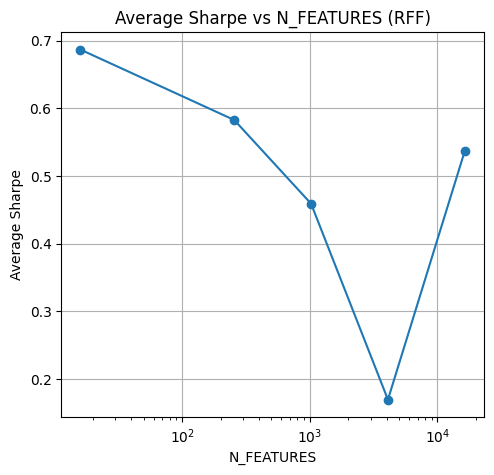

In [26]:
## Same run as 2 cells above, but runnign with grassman_v2, for subspace stability and effective rank diagnostics, 

#lets create rff transformations of the characteristics and then run the IPCA_Grass_estimation with the rff transformed characteristics, and see how the performance changes with the number of factors and the window length. 

GAMMA = 0.2
N_FEATURES = 64

# RFF transform needs a dense numeric matrix
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1

# Impute missing values cross-sectionally by date, then columnwise fallback
X_chars = X_chars.groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
X_chars = X_chars.fillna(X_chars.median()).fillna(0.0)

GAMMA = 0.2
window_len = 24
N_FEATURES_EFF = [16, 256, 1024, 4096, 16384,]
rff = RandomFourierFeatures(n_features=int(N_FEATURES / 2), gamma=GAMMA)
rff_data = rff.transform(X_chars, seed=1)
rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns =rff_cols)
df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
num_iter_rff = 3
results_by_factor_rff = {} 
#lets runf or different N_FEATURES_EFF values and store the results in a dictionary, but num_factors is always 4
for n_feat in N_FEATURES_EFF:
    print(f"\nRunning for N_FEATURES: {n_feat}")
    rff = RandomFourierFeatures(n_features=int(n_feat / 2), gamma=GAMMA)
    rff_data = rff.transform(X_chars, seed=1)
    rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
    rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns=rff_cols)
    df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
    
    all_results = []
    for i in range(num_iter_rff):
        print(f"Run {i+1}/{num_iter_rff} for N_FEATURES: {n_feat}")
        res = run_ipca_grass_v2(
            df_trunc=df_trunc_rff,
            char_feats=rff_cols,
            num_fact=4,  # keeping num_factors fixed at 4
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)

    results_by_factor_rff[n_feat] = {
        "avg_r2_oos": np.mean([res["r2_oos"] for res in all_results]),
        "avg_sharpe": np.mean([res["sharpe"] for res in all_results]),
        # ── paper diagnostics ──────────────────────────────────────────────
        "avg_subspace_stability": np.mean([res["mean_subspace_stability"] for res in all_results]),
        "avg_erank":             np.mean([res["mean_erank"] for res in all_results]),
        "avg_erank_collapse":    np.mean([res["erank_collapse_frac"] for res in all_results]),
    }
results_rff_df = pd.DataFrame(results_by_factor_rff).T
display(results_rff_df)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results_rff_df.index, results_rff_df["avg_sharpe"], marker="o")
plt.title("Average Sharpe vs N_FEATURES (RFF)")
plt.xlabel("N_FEATURES")
plt.ylabel("Average Sharpe")
plt.xscale("log")
plt.grid()

### Runs with updated stability metrics, but num iterations is only 1: (Add this to latex later)

In [13]:
## Same run as 2 cells above, but runnign with grassman_v2, for subspace stability and effective rank diagnostics, 


# RFF transform needs a dense numeric matrix
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1

# Impute missing values cross-sectionally by date, then columnwise fallback
X_chars = X_chars.groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
X_chars = X_chars.fillna(X_chars.median()).fillna(0.0)

GAMMA = 0.25
window_len = 12
N_FEATURES_RFF = [128, 1024, 4096, 16384]
num_factors_list = [2, 4, 8, 12]

df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
num_iter_rff = 10
results_by_factor_rff = {} 
# lets run for each num_factor and N_FEATURES_RFF combination, and store the results in a dictionary
for num_fact in num_factors_list:
    for n_feat in N_FEATURES_RFF:
        print(f"\nRunning for num_fact: {num_fact}, N_FEATURES: {n_feat}")
        rff = RandomFourierFeatures(n_features=int(n_feat / 2), gamma=GAMMA)
        rff_data = rff.transform(X_chars, seed=1)
        rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
        rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns=rff_cols)
        df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
        
        all_results = []
        for i in range(num_iter_rff):
            print(f"Run {i+1}/{num_iter_rff} for num_fact: {num_fact}, N_FEATURES: {n_feat}")
            res = run_ipca_grass_v2(
                df_trunc=df_trunc_rff,
                char_feats=rff_cols,
                num_fact=num_fact,
                window_len=window_len,
                max_nan=0.3,
                max_zero=0.3,
                min_non_nan_frac=0.7,
            )
            all_results.append(res)

        results_by_factor_rff[(num_fact, n_feat)] = {
            "avg_r2_oos": np.mean([r["r2_oos"] for r in all_results]),
            "avg_sharpe": np.mean([r["sharpe"] for r in all_results]),
            "avg_subspace_stability": np.mean([r["mean_subspace_stability"] for r in all_results]),
            "avg_max_principal_angle": np.mean([r["mean_max_principal_angle"] for r in all_results]),
            "avg_mean_principal_angle": np.mean([r["mean_mean_principal_angle"] for r in all_results]),
            "avg_geodesic_accel": np.mean([r["mean_geodesic_accel"] for r in all_results]),
            "avg_erank": np.mean([r["mean_erank"] for r in all_results]),
            "avg_erank_collapse": np.mean([r["erank_collapse_frac"] for r in all_results]),
            "avg_spectral_gap": np.mean([r["mean_spectral_gap"] for r in all_results]),
            "stability_dist_series": [r["stability_dist_series"] for r in all_results],
            "principal_angles_series": [r["principal_angles_series"] for r in all_results],
            "geodesic_accel_series": [r["geodesic_accel_series"] for r in all_results],
            "erank_series": [r["erank_series"] for r in all_results],
            "spectral_gap_series": [r["spectral_gap_series"] for r in all_results],
        }
        all_results.append(res)
results_rff_df = pd.DataFrame(results_by_factor_rff).T
display(results_rff_df)


Running for num_fact: 2, N_FEATURES: 128
Run 1/10 for num_fact: 2, N_FEATURES: 128
  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 1.001319e-01
  OOS R²                               : -0.3515
  Market-timing Sharpe (annualised)    : -1.106

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 1.9118  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.4579  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.3270  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0666  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 1.5435  (max = 2)
  erank collapse fraction              : 0.00

KeyboardInterrupt: 

In [16]:
results_rff_df = pd.DataFrame(results_by_factor_rff).T
display(results_rff_df)

avg_r2_oos avg_sharpe avg_subspace_stability avg_max_principal_angle  \
2 128   -57.120332   0.088002               1.907079                1.431933   
  1024  -82.630925   0.327589               1.989957                1.533408   
  4096   -0.122668   0.349249               1.998748                1.557999   
  16384 -59.780873   0.064694               1.999824                1.565811   
4 128   -66.143747   0.335847               2.737715                1.521467   
  1024   -0.015469    0.45327               2.821869                1.558869   
  4096    0.001782   0.360211               2.826965                1.565329   
  16384   -0.31507   0.396405                2.82808                1.568085   
8 128    -0.081961    0.30576               3.868313                1.548439   
  1024   -0.019726   0.380094               3.984037                 1.56261   
  4096   -0.132679   0.257735                3.99612                1.567277   

        avg_mean_principal_angle avg_geodesic_accel avg_erank  \
2 128                   1.311306           0.064367  1.537288   
  1024                  1.490562           0.008121  1.641602   
  4096                  1.542545           0.000957  1.649129   
  16384                 1.560139           0.000143  1.652312   
4 128                    1.35739           0.032955   2.56379   
  1024                  1.514603           0.002651  2.693509   
  4096                  1.544303           0.000604   2.65504   
  16384                 1.557948           0.000143  2.671956   
8 128                   1.353023            0.02507  3.558909   
  1024                  1.495782           0.003261  3.592795   
  4096                   1.53404           0.000769   3.59236   

        avg_erank_collapse avg_spectral_gap  \
2 128                  0.0         0.241803   
  1024                 0.0         0.317627   
  4096                 0.0         0.331842   
  16384                0.0         0.330446   
4 128             0.153191          0.06692   
  1024            0.110638         0.080334   
  4096            0.140426         0.075684   
  16384           0.119149         0.081595   
8 128             0.644681         0.005304   
  1024            0.644681         0.005434   
  4096            0.614894         0.005239   

                                     stability_dist_series  \
2 128    [[1.8470738815057983, 1.8308220006517064, 1.90...   
  1024   [[1.9962989008046461, 1.995286975208646, 1.988...   
  4096   [[1.9976285172997492, 1.9990160001944564, 1.99...   
  16384  [[1.9998942353759905, 1.9996787935287392, 1.99...   
4 128    [[2.671322972522598, 2.736186712816852, 2.6702...   
  1024   [[2.8215423561506907, 2.821633470305277, 2.820...   
  4096   [[2.826442782077507, 2.8269880019690907, 2.827...   
  16384  [[2.8280898661915215, 2.8280146694993196, 2.82...   
8 128    [[3.858958763611615, 3.8618979271538496, 3.864...   
  1024   [[3.9856303800313153, 3.980655686201594, 3.983...   
  4096   [[3.9953170856148, 3.9961477486913806, 3.99754...   

                                   principal_angles_series  \
2 128    [[[1.3408234717174414, 1.0562551501286683], [1...   
  1024   [[[1.523689911154932, 1.4987759290433538], [1....   
  4096   [[[1.5572015842510734, 1.503251662201055], [1....   
  16384  [[[1.5691207581587197, 1.556348813176835], [1....   
4 128    [[[1.553785801668101, 1.2984280103470645, 1.18...   
  1024   [[[1.5521940999108759, 1.506646829370578, 1.49...   
  4096   [[[1.56883829785023, 1.5419104340025869, 1.531...   
  16384  [[[1.5670085389218884, 1.5642128288589943, 1.5...   
8 128    [[[1.5532813200033087, 1.5100463165814904, 1.4...   
  1024   [[[1.5694748988826273, 1.552641182914959, 1.53...   
  4096   [[[1.5650621082433356, 1.5593703850501826, 1.5...   

                                     geodesic_accel_series  \
2 128    [[-0.016251880854091905, 0.07356527509771182, ...   
  1024   [[-0.0010119255960001627, -0.00641287943878965...   
  4096   [[0.001387482894

In [17]:
#lets store these results in a pickle file and save in the current directory, so that we can load it later and analyze the results without having to run the whole thing again, as it takes a long time to run with all the combinations of num_factors and N_FEATURES_RFF and num_iter_rff.
import pickle
with open("ipca_rff_results_iter1.pkl", "wb") as f:
    pickle.dump(results_by_factor_rff, f)
# To load the results later, you can use:
with open("ipca_rff_results_iter1.pkl", "rb") as f:
    loaded_results = pickle.load(f)

In [ ]:
# lets plot

AttributeError: 'dict' object has no attribute 'head'

### Run with ridge shrinkage values, and add some parallelization

In [11]:
# ---------------------------------------------------------------------------
# Grassmann-IPCA  ·  RFF × k × z  grid sweep  —  notebook cell
# ---------------------------------------------------------------------------
# All heavy logic lives in _grass_worker.py (must be in the same directory).
# This cell only:
#   1. Sets the grid parameters
#   2. Prepares the input data (the two lines that need notebook variables)
#   3. Calls the pipeline functions and displays results
# ---------------------------------------------------------------------------

from src._grass_worker import (
    build_rff_inputs, build_jobs, run_sweep, aggregate, make_results_df,
    Z_VALUES, _z_label,
    GAMMA, WINDOW_LEN, N_FEATURES_RFF, NUM_FACTORS_LIST, NUM_ITER_RFF,
)

# ===========================================================================
# 1.  (OPTIONAL) OVERRIDE GRID DEFAULTS
#     Uncomment and edit any of these to override the defaults in _grass_worker.py
# ===========================================================================
N_FEATURES_RFF   = [ 64, 256, 1000, 4000, 12000 ]
NUM_FACTORS_LIST = [4,] # Its established that 4 factors is a sweet spot.
NUM_ITER_RFF     = 5
WINDOW_LEN       = 12
GAMMA            = 0.25
Z_VALUES         = [1e-2,1e-1, 0, 1e1, 1e2]


# ===========================================================================
# 2.  PREPARE INPUT DATA  (needs notebook variables: char_feats_final, df_trunc_extended)
# ===========================================================================
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1
X_chars = (
    X_chars
    .groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
    .fillna(X_chars.median())
    .fillna(0.0)
)


# ===========================================================================
# 3.  RUN PIPELINE
# ===========================================================================
print("Pre-computing RFF features ...")
rff_inputs = build_rff_inputs(
    X_chars          = X_chars,
    df_base          = df_trunc_extended,
    n_features_rff   = N_FEATURES_RFF,
    num_iter_rff     = NUM_ITER_RFF,
    gamma            = GAMMA,
    RandomFourierFeatures = RandomFourierFeatures,   # already imported in notebook
)
print(f"  {len(rff_inputs)} RFF datasets ready.")

jobs = build_jobs(
    rff_inputs       = rff_inputs,
    num_factors_list = NUM_FACTORS_LIST,
    n_features_rff   = N_FEATURES_RFF,
    z_values         = Z_VALUES,
    num_iter_rff     = NUM_ITER_RFF,
    window_len       = WINDOW_LEN,
)

raw_results          = run_sweep(jobs)
results_by_factor_rff = aggregate(raw_results)
results_rff_df       = make_results_df(results_by_factor_rff)


Pre-computing RFF features ...
  25 RFF datasets ready.
Dispatching 125 jobs across 7 workers (cost range 512–96000, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.398403e-02
  OOS R²                               : -0.0198
  Market-timing Sharpe (annualised)    : 0.398

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 2.8280  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5683  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.5565  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0002  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 2.6062  (max = 4)
  erank collapse fraction              : 0.1667  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ───────

/Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Python(14075) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.274284e-02
  OOS R²                               : -0.0027
  Market-timing Sharpe (annualised)    : 0.520

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 2.8279  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5674  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.5556  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0002  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 2.9207  (max = 4)
  erank collapse fraction              : 0.0625  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ───────

...

[Parallel(n_jobs=7)]: Done 100 out of 125 | elapsed: 514.5min remaining: 128.6min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.504644e-02
  OOS R²                               : -0.0344
  Market-timing Sharpe (annualised)    : -0.747

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 2.6211  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5098  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.2423  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0710  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ���───────────────────
  Mean erank                           : 2.7294  (max = 4)
  erank collapse fraction              : 0.1458  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────

[Parallel(n_jobs=7)]: Done 113 out of 125 | elapsed: 522.1min remaining: 55.4min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.151529e-02
  OOS R²                               : 0.0142
  Market-timing Sharpe (annualised)    : 0.534

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 1.4935  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.1163  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 0.5275  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.4095  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 3.0163  (max = 4)
  erank collapse fraction              : 0.0208  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done 125 out of 125 | elapsed: 553.3min finished


In [12]:


# ===========================================================================
# 4.  DISPLAY
# ===========================================================================
display(results_rff_df)

print("\n── Sharpe by (k, P) for each z ──────────────────────────────────")
for z in Z_VALUES:
    z_key    = _z_label(z)
    slice_df = results_rff_df.xs(z_key, level="z")["avg_sharpe"].unstack("P")
    print(f"\n  z = {z}  ({z_key})")
    display(slice_df.round(3))

avg_r2_oos  avg_sharpe  avg_subspace_stability  \
k P     z                                                         
4 64    z=0e+00   -0.034699    0.469125                2.642771   
        z=1e+01    0.005697    0.503682                1.506046   
        z=1e+02    0.002079    0.467304                1.031221   
        z=1e-01   -0.013684    0.196360                2.614887   
        z=1e-02   -0.006985    0.461180                2.648555   
  256   z=0e+00   -0.001723    0.373813                2.790690   
        z=1e+01    0.003952    0.469003                1.830610   
        z=1e+02    0.003030    0.465838                1.286864   
        z=1e-01   -0.000721    0.161476                2.783969   
        z=1e-02   -0.003521    0.463285                2.792273   
  1000  z=0e+00   -0.004357    0.204200                2.821371   
        z=1e+01    0.008303    0.447480                2.093153   
        z=1e+02    0.006090    0.452940                1.614375   
        z=1e-01   -0.005888    0.326704                2.821396   
        z=1e-02   -0.005528    0.230204                2.821861   
  4000  z=0e+00   -0.011739    0.310559                2.826951   
        z=1e+01    0.013106    0.584013                2.540465   
        z=1e+02    0.009987    0.491804                1.865314   
        z=1e-01   -0.007741   -0.022296                2.826866   
        z=1e-02   -0.001306    0.547546                2.826925   
  12000 z=0e+00   -0.015281    0.069142                2.827959   
        z=1e+01    0.014602    0.557119                2.769147   
        z=1e+02    0.010262    0.484840                2.109229   
        z=1e-01    0.002992    0.485858                2.827943   
        z=1e-02    0.004547    0.460572                2.827964   

                 avg_max_principal_angle  avg_mean_principal_angle  \
k P     z                                                            
4 64    z=0e+00                 1.502562                  1.260166   
        z=1e+01                 1.118331                  0.535278   
        z=1e+02                 0.894911                  0.286665   
        z=1e-01                 1.499791                  1.235012   
        z=1e-02                 1.507823                  1.264251   
  256   z=0e+00                 1.540469                  1.434779   
        z=1e+01                 1.285589                  0.705321   
        z=1e+02                 1.056703                  0.405300   
        z=1e-01                 1.539111                  1.423987   
        z=1e-02                 1.541545                  1.438374   
  1000  z=0e+00                 1.558156                  1.512544   
        z=1e+01                 1.387779                  0.865568   
        z=1e+02                 1.190354                  0.575046   
        z=1e-01                 1.558999                  1.512880   
        z=1e-02                 1.559301                  1.514791   
  4000  z=0e+00                 1.565233                  1.544216   
        z=1e+01                 1.481076                  1.177654   
        z=1e+02                 1.310086                  0.719315   
        z=1e-01                 1.564963                  1.543423   
        z=1e-02                 1.565551                  1.544021   
  12000 z=0e+00                 1.567391                  1.555726   
        z=1e+01                 1.538894                  1.405448   
        z=1e+02                 1.380752                  0.873314   
        z=1e-01                 1.567182                  1.555448   
        z=1e-02                 1.567597                  1.555887   

                 avg_geodesic_accel  avg_erank  avg_erank_collapse  \
k P     z                                                            
4 64    z=0e+00            0.062023   2.469392            0.208333   
        z=1e+01            0.410998   3.042618            0.029167   
        z=1e+02            0.514642 


── Sharpe by (k, P) for each z ──────────────────────────────────

  z = 0.01  (z=1e-02)


P,64,256,1000,4000,12000
k,,,,,
4,0.461,0.463,0.23,0.548,0.461



  z = 0.1  (z=1e-01)


P,64,256,1000,4000,12000
k,,,,,
4,0.196,0.161,0.327,-0.022,0.486


...

P,64,256,1000,4000,12000
k,,,,,
4,0.469,0.374,0.204,0.311,0.069



  z = 10.0  (z=1e+01)


P,64,256,1000,4000,12000
k,,,,,
4,0.504,0.469,0.447,0.584,0.557



  z = 100.0  (z=1e+02)


P,64,256,1000,4000,12000
k,,,,,
4,0.467,0.466,0.453,0.492,0.485


In [13]:
#First lets save the results in this directory, in a pickle file
import pickle
with open("ipca_rff_5yrs_diff_z&n_features.pkl", "wb") as f:    
    pickle.dump(results_by_factor_rff, f)
    print("Results saved to ipca_rff_5yrs_diff_z&n_features.pkl")
    

Results saved to ipca_rff_5yrs_diff_z&n_features.pkl


<Figure size 640x480 with 0 Axes>

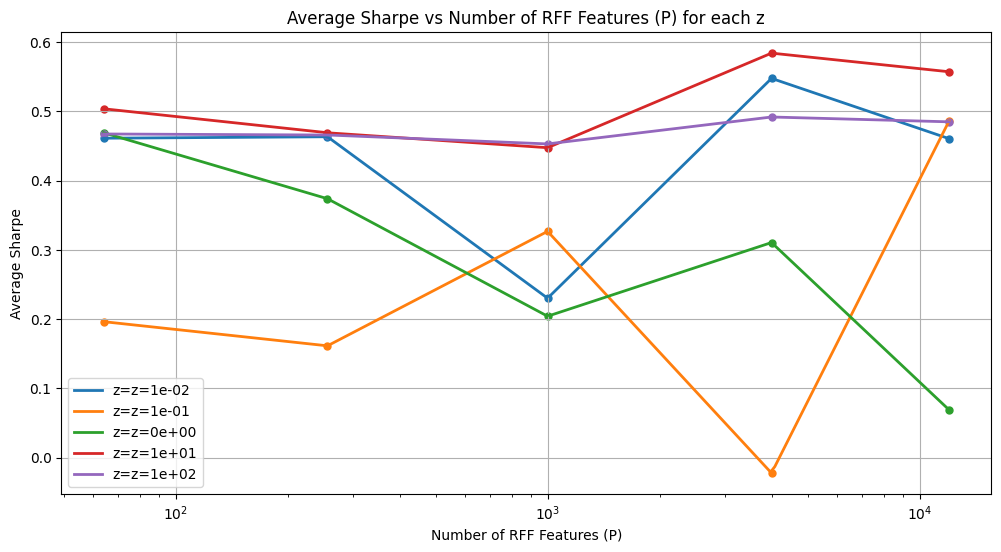

In [26]:

# Plot Sharpe vs N_FEATURES (P) for each z (single smooth curve per z)
plt.clf()
plt.figure(figsize=(12, 6))
for z in Z_VALUES:
    z_key = _z_label(z)
    slice_df = results_rff_df.xs(z_key, level="z")["avg_sharpe"].unstack("k")
    if 4 in slice_df.columns:
        series = slice_df[4].sort_index()  # P on index
        series_interp = series.interpolate(method="index", limit_direction="both")
        plt.plot(series_interp.index, series_interp.values, marker="o", label=f"z={z_key}")

plt.title("Average Sharpe vs Number of RFF Features (P) for each z")
plt.xlabel("Number of RFF Features (P)")
ax = plt.gca()
ax.cla()

for z in Z_VALUES:
    z_key = _z_label(z)
    slice_df = results_rff_df.xs(z_key, level="z")["avg_sharpe"].unstack("k")
    if 4 in slice_df.columns:
        series = slice_df[4].sort_index()
        x = series.index.to_numpy(dtype=float)
        y = series.to_numpy()

        x_new = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
        y_new = np.interp(np.log10(x_new), np.log10(x), y)

        ax.plot(x_new, y_new, linewidth=2, label=f"z={z_key}")
        ax.scatter(x, y, s=25)

ax.set_title("Average Sharpe vs Number of RFF Features (P) for each z")
ax.set_xlabel("Number of RFF Features (P)")
ax.set_ylabel("Average Sharpe")
ax.set_xscale("log")
plt.grid()
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

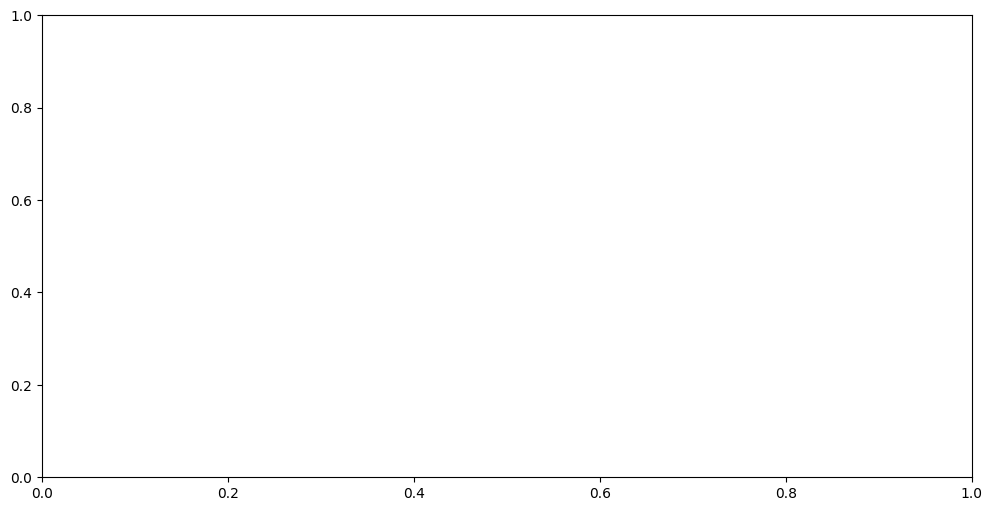

In [27]:
# let plot the subspace stability diagnostic (d_proj) vs N_FEATURES for each z, with one curve per z, and error bars showing the variability across runs. This will help us understand if higher Sharpe at certain z and P is associated with more stable factor subspaces.
plt.clf()
plt.figure(figsize=(12, 6))
for z in Z_VALUES:
    z_key = _z_label(z)
    slice_df = results_rff_df.xs(z_key, level="z")["avg_subspace_stability"].unstack("k")
    if 4 in slice_df.columns:
        series = slice_df[4].sort_index()  # P on index
        series_interp = series.interpolate(method="index", limit_direction="both")
        plt.plot(series_interp.index, series_interp.values, marker="o", label=f"z={z_key}")
plt.title("Average Subspace Stability (d_proj) vs Number of RFF Features (P) for each z")
plt.xlabel("Number of RFF Features (P)")
plt.ylabel("Average Subspace Stability (d_proj)")
ax = plt.gca()
ax.cla()

### Simulations to find the best k, under the best Z(10)

In [28]:
# ---------------------------------------------------------------------------
# Grassmann-IPCA  ·  RFF × k × z  grid sweep  —  notebook cell
# ---------------------------------------------------------------------------
# All heavy logic lives in _grass_worker.py (must be in the same directory).
# This cell only:
#   1. Sets the grid parameters
#   2. Prepares the input data (the two lines that need notebook variables)
#   3. Calls the pipeline functions and displays results
# ---------------------------------------------------------------------------

from src._grass_worker import (
    build_rff_inputs, build_jobs, run_sweep, aggregate, make_results_df,
    Z_VALUES, _z_label,
    GAMMA, WINDOW_LEN, N_FEATURES_RFF, NUM_FACTORS_LIST, NUM_ITER_RFF,
)

# ===========================================================================
# 1.  (OPTIONAL) OVERRIDE GRID DEFAULTS
#     Uncomment and edit any of these to override the defaults in _grass_worker.py
# ===========================================================================
N_FEATURES_RFF   = [ 4000 ]
NUM_FACTORS_LIST = [2, 4, 6, 8, 10, 12] # Its established that 4 factors is a sweet spot.
NUM_ITER_RFF     = 5
WINDOW_LEN       = 12
GAMMA            = 0.25
Z_VALUES         = [1e1]


# ===========================================================================
# 2.  PREPARE INPUT DATA  (needs notebook variables: char_feats_final, df_trunc_extended)
# ===========================================================================
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1
X_chars = (
    X_chars
    .groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
    .fillna(X_chars.median())
    .fillna(0.0)
)


# ===========================================================================
# 3.  RUN PIPELINE
# ===========================================================================
print("Pre-computing RFF features ...")
rff_inputs = build_rff_inputs(
    X_chars          = X_chars,
    df_base          = df_trunc_extended,
    n_features_rff   = N_FEATURES_RFF,
    num_iter_rff     = NUM_ITER_RFF,
    gamma            = GAMMA,
    RandomFourierFeatures = RandomFourierFeatures,   # already imported in notebook
)
print(f"  {len(rff_inputs)} RFF datasets ready.")

jobs = build_jobs(
    rff_inputs       = rff_inputs,
    num_factors_list = NUM_FACTORS_LIST,
    n_features_rff   = N_FEATURES_RFF,
    z_values         = Z_VALUES,
    num_iter_rff     = NUM_ITER_RFF,
    window_len       = WINDOW_LEN,
)

raw_results          = run_sweep(jobs)
results_by_factor_rff = aggregate(raw_results)
results_rff_df       = make_results_df(results_by_factor_rff)


Pre-computing RFF features ...
  5 RFF datasets ready.
Dispatching 30 jobs across 7 workers (cost range 11314–166277, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
Python(27880) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27881) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27882) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27883) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27886) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27887) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27890) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.109498e-02
  OOS R²                               : 0.0200
  Market-timing Sharpe (annualised)    : 0.489

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 4.2154  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5610  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.3112  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0349  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 4.4831  (max = 10)
  erank collapse fraction              : 0.5417  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ───────

[Parallel(n_jobs=7)]: Done   3 out of  30 | elapsed:  6.7min remaining: 60.2min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.236017e-02
  OOS R²                               : 0.0026
  Market-timing Sharpe (annualised)    : 0.438

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 4.6621  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5647  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.3427  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0393  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 4.6734  (max = 12)
  erank collapse fraction              : 0.7500  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ───────

...

[Parallel(n_jobs=7)]: Done  23 out of  30 | elapsed: 21.9min remaining:  6.7min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.172020e-02
  OOS R²                               : 0.0114
  Market-timing Sharpe (annualised)    : 0.597

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 2.5614  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.4955  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.2004  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0873  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 2.9714  (max = 4)
  erank collapse fraction              : 0.0208  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done  27 out of  30 | elapsed: 21.9min remaining:  2.4min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.241278e-02
  OOS R²                               : 0.0019
  Market-timing Sharpe (annualised)    : 0.461

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 1.7758  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.3514  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.1600  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.1745  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 1.8211  (max = 2)
  erank collapse fraction              : 0.0000  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done  30 out of  30 | elapsed: 23.2min finished


In [29]:
results_rff_df

,,,avg_r2_oos,avg_sharpe,avg_subspace_stability,avg_max_principal_angle,avg_mean_principal_angle,avg_geodesic_accel,avg_erank,avg_erank_collapse,avg_spectral_gap
k,P,z,,,,,,,,,
2,4000,z=1e+01,0.000401,0.226911,1.777432,1.355581,1.158766,0.146852,1.819185,0.000000,0.481462
4,4000,z=1e+01,0.010810,0.529014,2.557527,1.490673,1.195008,0.078272,2.965567,0.029167,0.138072
6,4000,z=1e+01,0.012948,0.553831,3.180260,1.526749,1.231159,0.063450,3.740098,0.208333,0.052272
8,4000,z=1e+01,0.013634,0.512795,3.728756,1.551549,1.277067,0.050859,4.219013,0.525000,0.016469
10,4000,z=1e+01,0.010593,0.508329,4.210816,1.559938,1.307986,0.042255,4.530078,0.562500,0.004091
12,4000,z=1e+01,0.006822,0.489258,4.656194,1.564306,1.338340,0.038782,4.697514,0.720833,0.000338


### best k(6), different z

In [30]:


# ---------------------------------------------------------------------------
# Grassmann-IPCA  ·  RFF × k × z  grid sweep  —  notebook cell
# ---------------------------------------------------------------------------
# All heavy logic lives in _grass_worker.py (must be in the same directory).
# This cell only:
#   1. Sets the grid parameters
#   2. Prepares the input data (the two lines that need notebook variables)
#   3. Calls the pipeline functions and displays results
# ---------------------------------------------------------------------------

from src._grass_worker import (
    build_rff_inputs, build_jobs, run_sweep, aggregate, make_results_df,
    Z_VALUES, _z_label,
    GAMMA, WINDOW_LEN, N_FEATURES_RFF, NUM_FACTORS_LIST, NUM_ITER_RFF,
)

# ===========================================================================
# 1.  (OPTIONAL) OVERRIDE GRID DEFAULTS
#     Uncomment and edit any of these to override the defaults in _grass_worker.py
# ===========================================================================
N_FEATURES_RFF   = [ 4000 ]
NUM_FACTORS_LIST = [6, ] # Its established that 4 factors is a sweet spot.
NUM_ITER_RFF     = 5
WINDOW_LEN       = 12
GAMMA            = 0.25
Z_VALUES         = [0, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100]


# ===========================================================================
# 2.  PREPARE INPUT DATA  (needs notebook variables: char_feats_final, df_trunc_extended)
# ===========================================================================
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1
X_chars = (
    X_chars
    .groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
    .fillna(X_chars.median())
    .fillna(0.0)
)


# ===========================================================================
# 3.  RUN PIPELINE
# ===========================================================================
print("Pre-computing RFF features ...")
rff_inputs = build_rff_inputs(
    X_chars          = X_chars,
    df_base          = df_trunc_extended,
    n_features_rff   = N_FEATURES_RFF,
    num_iter_rff     = NUM_ITER_RFF,
    gamma            = GAMMA,
    RandomFourierFeatures = RandomFourierFeatures,   # already imported in notebook
)
print(f"  {len(rff_inputs)} RFF datasets ready.")

jobs = build_jobs(
    rff_inputs       = rff_inputs,
    num_factors_list = NUM_FACTORS_LIST,
    n_features_rff   = N_FEATURES_RFF,
    z_values         = Z_VALUES,
    num_iter_rff     = NUM_ITER_RFF,
    window_len       = WINDOW_LEN,
)

raw_results          = run_sweep(jobs)
results_by_factor_rff = aggregate(raw_results)
results_rff_df       = make_results_df(results_by_factor_rff)

Pre-computing RFF features ...
  5 RFF datasets ready.
Dispatching 50 jobs across 7 workers (cost range 58788–58788, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
Python(29249) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29250) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29251) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29252) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29253) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29254) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29255) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.259417e-02
  OOS R²                               : -0.0006
  Market-timing Sharpe (annualised)    : 0.504

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 3.4613  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5665  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.5377  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0007  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ��───────────────────
  Mean erank                           : 3.2800  (max = 6)
  erank collapse fraction              : 0.3333  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ──────

[Parallel(n_jobs=7)]: Done   3 out of  50 | elapsed:  9.5min remaining: 149.2min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.324700e-02
  OOS R²                               : -0.0096
  Market-timing Sharpe (annualised)    : 0.518

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 3.4616  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5669  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.5392  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────��───────────
  Mean |Δd_proj|                       : 0.0006  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 3.2984  (max = 6)
  erank collapse fraction              : 0.2917  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ──────

...

Python(31226) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.185876e-02
  OOS R²                               : 0.0095
  Market-timing Sharpe (annualised)    : 0.625

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 2.3183  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.4337  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 0.7346  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.1432  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 4.0616  (max = 6)
  erank collapse fraction              : 0.3333  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done  45 out of  50 | elapsed: 66.4min remaining:  7.4min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.223798e-02
  OOS R²                               : 0.0043
  Market-timing Sharpe (annualised)    : 0.536

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 2.1208  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.4089  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 0.6325  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.1949  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 4.0714  (max = 6)
  erank collapse fraction              : 0.3542  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done  50 out of  50 | elapsed: 68.1min finished


In [31]:
results_rff_df

avg_r2_oos  avg_sharpe  avg_subspace_stability  \
k P    z                                                         
6 4000 z=0e+00   -0.008789    0.525987                3.461452   
       z=1e+00    0.007850    0.571926                3.456901   
       z=1e+01    0.011631    0.582990                3.178693   
       z=1e+02    0.005001    0.499140                2.083109   
       z=1e-01    0.006323    0.441376                3.461402   
       z=2e+00    0.004288    0.468143                3.444011   
       z=2e+01    0.010728    0.466987                2.832048   
       z=5e+00    0.002456    0.471504                3.366055   
       z=5e+01    0.007142    0.543279                2.318659   
       z=5e-01    0.006440    0.432392                3.460273   

                avg_max_principal_angle  avg_mean_principal_angle  \
k P    z                                                            
6 4000 z=0e+00                 1.566629                  1.538330   
       z=1e+00                 1.564557                  1.518894   
       z=1e+01                 1.528879                  1.231442   
       z=1e+02                 1.379633                  0.613134   
       z=1e-01                 1.565917                  1.537993   
       z=2e+00                 1.561211                  1.486352   
       z=2e+01                 1.490544                  1.015560   
       z=5e+00                 1.548749                  1.381494   
       z=5e+01                 1.413981                  0.732793   
       z=5e-01                 1.565935                  1.532093   

                avg_geodesic_accel  avg_erank  avg_erank_collapse  \
k P    z                                                            
6 4000 z=0e+00            0.000658   3.248189            0.375000   
       z=1e+00            0.001914   3.592356            0.270833   
       z=1e+01            0.054781   3.730685            0.237500   
       z=1e+02            0.209588   4.069685            0.370833   
       z=1e-01            0.000691   3.492738            0.350000   
       z=2e+00            0.005706   3.601661            0.237500   
       z=2e+01            0.107037   3.902840            0.150000   
       z=5e+00            0.025951   3.660076            0.254167   
       z=5e+01            0.170359   4.065838            0.287500   
       z=5e-01            0.001133   3.609662            0.237500   

                avg_spectral_gap  
k P    z                          
6 4000 z=0e+00          0.019370  
       z=1e+00          0.035862  
       z=1e+01          0.050261  
       z=1e+02          0.143269  
       z=1e-01          0.032842  
       z=2e+00          0.037875  
       z=2e+01          0.069794  
       z=5e+00          0.043084  
       z=5e+01          0.119905  
       z=5e-01          0.038205

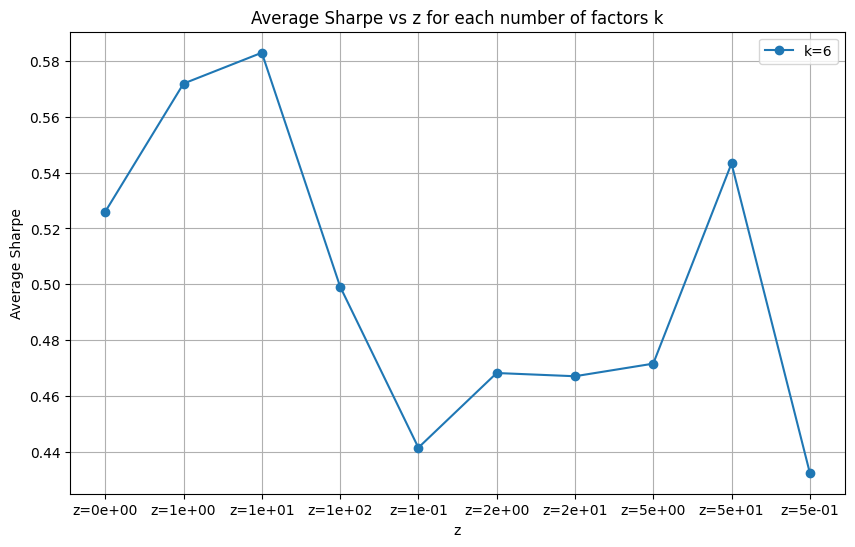

In [33]:
#plot Sharpe vs z 
plt.figure(figsize=(10, 6))
for num_fact in NUM_FACTORS_LIST:
    slice_df = results_rff_df.xs(num_fact, level="k")["avg_sharpe"].unstack("P")
    if 4000 in slice_df.columns:
        series = slice_df[4000].sort_index()  # z on index
        series_interp = series.interpolate(method="index", limit_direction="both")
        plt.plot(series_interp.index, series_interp.values, marker="o", label=f"k={num_fact}")
plt.title("Average Sharpe vs z for each number of factors k")
plt.xlabel("z")
plt.ylabel("Average Sharpe")

plt.grid()
plt.legend()
plt.show()

/var/folders/js/pgf30x597b53rt2mghx7jpmm0000gn/T/ipykernel_5375/1109488053.py:12: RuntimeWarning: divide by zero encountered in log10
  x_new = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
/Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/.venv/lib/python3.11/site-packages/numpy/_core/function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
/Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/.venv/lib/python3.11/site-packages/numpy/_core/function_base.py:173: RuntimeWarning: invalid value encountered in add
  y += start
/var/folders/js/pgf30x597b53rt2mghx7jpmm0000gn/T/ipykernel_5375/1109488053.py:13: RuntimeWarning: divide by zero encountered in log10
  y_new = np.interp(np.log10(x_new), np.log10(x), y)


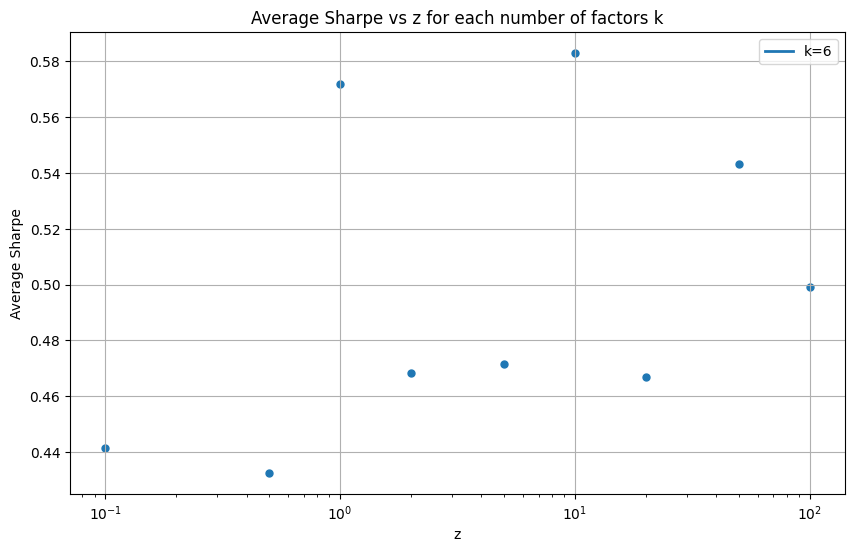

In [39]:
#z values are not in ascending order, so we need to sort them before plotting
plt.figure(figsize=(10, 6))
for num_fact in NUM_FACTORS_LIST:
    slice_df = results_rff_df.xs(num_fact, level="k")["avg_sharpe"].unstack("P")
    if 4000 in slice_df.columns:
        series = slice_df[4000].sort_index()  # z on index
        # parse z labels like "z=1e+00" into floats
        z_vals = pd.Series(series.index).str.replace("z=", "", regex=False)
        x = z_vals.astype(float).to_numpy()
        y = series.to_numpy()

        x_new = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
        y_new = np.interp(np.log10(x_new), np.log10(x), y)

        plt.plot(x_new, y_new, linewidth=2, label=f"k={num_fact}")
        plt.scatter(x, y, s=25)
plt.xscale("log")
plt.title("Average Sharpe vs z for each number of factors k")
plt.xlabel("z")
plt.ylabel("Average Sharpe")    
plt.grid()
plt.legend()
plt.show()


### Run 5 - P scaling k=6, z=10, P ∈ {64, 256, 1000, 4000, 12000}

In [40]:


# ---------------------------------------------------------------------------
# Grassmann-IPCA  ·  RFF × k × z  grid sweep  —  notebook cell
# ---------------------------------------------------------------------------
# All heavy logic lives in _grass_worker.py (must be in the same directory).
# This cell only:
#   1. Sets the grid parameters
#   2. Prepares the input data (the two lines that need notebook variables)
#   3. Calls the pipeline functions and displays results
# ---------------------------------------------------------------------------

from src._grass_worker import (
    build_rff_inputs, build_jobs, run_sweep, aggregate, make_results_df,
    Z_VALUES, _z_label,
    GAMMA, WINDOW_LEN, N_FEATURES_RFF, NUM_FACTORS_LIST, NUM_ITER_RFF,
)

# ===========================================================================
# 1.  (OPTIONAL) OVERRIDE GRID DEFAULTS
#     Uncomment and edit any of these to override the defaults in _grass_worker.py
# ===========================================================================
N_FEATURES_RFF   = [ 64, 256, 1000, 4000, 12000 ]
NUM_FACTORS_LIST = [6, ] # Its established that 4 factors is a sweet spot.
NUM_ITER_RFF     = 5
WINDOW_LEN       = 12
GAMMA            = 0.25
Z_VALUES         = [10,]


# ===========================================================================
# 2.  PREPARE INPUT DATA  (needs notebook variables: char_feats_final, df_trunc_extended)
# ===========================================================================
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1
X_chars = (
    X_chars
    .groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
    .fillna(X_chars.median())
    .fillna(0.0)
)


# ===========================================================================
# 3.  RUN PIPELINE
# ===========================================================================
print("Pre-computing RFF features ...")
rff_inputs = build_rff_inputs(
    X_chars          = X_chars,
    df_base          = df_trunc_extended,
    n_features_rff   = N_FEATURES_RFF,
    num_iter_rff     = NUM_ITER_RFF,
    gamma            = GAMMA,
    RandomFourierFeatures = RandomFourierFeatures,   # already imported in notebook
)
print(f"  {len(rff_inputs)} RFF datasets ready.")

jobs = build_jobs(
    rff_inputs       = rff_inputs,
    num_factors_list = NUM_FACTORS_LIST,
    n_features_rff   = N_FEATURES_RFF,
    z_values         = Z_VALUES,
    num_iter_rff     = NUM_ITER_RFF,
    window_len       = WINDOW_LEN,
)

raw_results          = run_sweep(jobs)
results_by_factor_rff = aggregate(raw_results)
results_rff_df       = make_results_df(results_by_factor_rff)

Pre-computing RFF features ...
  25 RFF datasets ready.
Dispatching 25 jobs across 7 workers (cost range 941–176363, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
Python(31773) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31774) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31775) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31776) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31777) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31778) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(31779) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.154598e-02
  OOS R²                               : 0.0138
  Market-timing Sharpe (annualised)    : 0.550

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 3.1561  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5345  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.2207  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0630  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 3.7050  (max = 6)
  erank collapse fraction              : 0.2500  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done   2 out of  25 | elapsed:  5.2min remaining: 59.3min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.262937e-02
  OOS R²                               : -0.0011
  Market-timing Sharpe (annualised)    : 0.473

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 3.1786  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5210  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.2312  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0647  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ��───────────────────
  Mean erank                           : 3.6938  (max = 6)
  erank collapse fraction              : 0.2708  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ──────

...

[Parallel(n_jobs=7)]: Done  17 out of  25 | elapsed: 16.3min remaining:  7.7min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.215554e-02
  OOS R²                               : 0.0054
  Market-timing Sharpe (annualised)    : 0.568

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 1.6797  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.2738  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 0.4488  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.3011  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 3.8679  (max = 6)
  erank collapse fraction              : 0.4167  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done  20 out of  25 | elapsed: 18.0min remaining:  4.5min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.299939e-02
  OOS R²                               : -0.0062
  Market-timing Sharpe (annualised)    : 0.470

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 3.4102  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5552  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.4324  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0145  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 3.6726  (max = 6)
  erank collapse fraction              : 0.2917  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ───────

[Parallel(n_jobs=7)]: Done  23 out of  25 | elapsed: 260.8min remaining: 22.7min
[Parallel(n_jobs=7)]: Done  25 out of  25 | elapsed: 260.8min finished


In [41]:
results_rff_df

avg_r2_oos  avg_sharpe  avg_subspace_stability  \
k P     z                                                         
6 64    z=1e+01    0.003898    0.519035                1.675171   
  256   z=1e+01    0.001465    0.437993                1.994363   
  1000  z=1e+01    0.004988    0.422232                2.514904   
  4000  z=1e+01    0.005555    0.461655                3.173147   
  12000 z=1e+01   -0.000231    0.489866                3.410083   

                 avg_max_principal_angle  avg_mean_principal_angle  \
k P     z                                                            
6 64    z=1e+01                 1.251352                  0.447603   
  256   z=1e+01                 1.362649                  0.578846   
  1000  z=1e+01                 1.447339                  0.835991   
  4000  z=1e+01                 1.527079                  1.228586   
  12000 z=1e+01                 1.555469                  1.433566   

                 avg_geodesic_accel  avg_erank  avg_erank_collapse  \
k P     z                                                            
6 64    z=1e+01            0.311409   3.815432            0.441667   
  256   z=1e+01            0.199278   4.024353            0.358333   
  1000  z=1e+01            0.138299   4.022472            0.187500   
  4000  z=1e+01            0.058898   3.733179            0.250000   
  12000 z=1e+01            0.014780   3.628756            0.279167   

                 avg_spectral_gap  
k P     z                          
6 64    z=1e+01          0.100962  
  256   z=1e+01          0.130583  
  1000  z=1e+01          0.096706  
  4000  z=1e+01          0.048782  
  12000 z=1e+01          0.043251

## Runn 6 - joink k, z grid

In [7]:


# ---------------------------------------------------------------------------
# Grassmann-IPCA  ·  RFF × k × z  grid sweep  —  notebook cell
# ---------------------------------------------------------------------------
# All heavy logic lives in _grass_worker.py (must be in the same directory).
# This cell only:
#   1. Sets the grid parameters
#   2. Prepares the input data (the two lines that need notebook variables)
#   3. Calls the pipeline functions and displays results
# ---------------------------------------------------------------------------

from src._grass_worker import (
    build_rff_inputs, build_jobs, run_sweep, aggregate, make_results_df,
    Z_VALUES, _z_label,
    GAMMA, WINDOW_LEN, N_FEATURES_RFF, NUM_FACTORS_LIST, NUM_ITER_RFF,
)

# ===========================================================================
# 1.  (OPTIONAL) OVERRIDE GRID DEFAULTS
#     Uncomment and edit any of these to override the defaults in _grass_worker.py
# ===========================================================================
N_FEATURES_RFF   = [ 4000 ]
NUM_FACTORS_LIST = [2, 4, 6, 8, 12 ] # Its established that 4 factors is a sweet spot.
NUM_ITER_RFF     = 5
WINDOW_LEN       = 12
GAMMA            = 0.25
Z_VALUES         = [0, 1, 5, 10, 50, 100]


# ===========================================================================
# 2.  PREPARE INPUT DATA  (needs notebook variables: char_feats_final, df_trunc_extended)
# ===========================================================================
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1
X_chars = (
    X_chars
    .groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
    .fillna(X_chars.median())
    .fillna(0.0)
)


# ===========================================================================
# 3.  RUN PIPELINE
# ===========================================================================
print("Pre-computing RFF features ...")
rff_inputs = build_rff_inputs(
    X_chars          = X_chars,
    df_base          = df_trunc_extended,
    n_features_rff   = N_FEATURES_RFF,
    num_iter_rff     = NUM_ITER_RFF,
    gamma            = GAMMA,
    RandomFourierFeatures = RandomFourierFeatures,   # already imported in notebook
)
print(f"  {len(rff_inputs)} RFF datasets ready.")

jobs = build_jobs(
    rff_inputs       = rff_inputs,
    num_factors_list = NUM_FACTORS_LIST,
    n_features_rff   = N_FEATURES_RFF,
    z_values         = Z_VALUES,
    num_iter_rff     = NUM_ITER_RFF,
    window_len       = WINDOW_LEN,
)

raw_results          = run_sweep(jobs)
results_by_factor_rff = aggregate(raw_results)
results_rff_df_kz_grid       = make_results_df(results_by_factor_rff)

Pre-computing RFF features ...
  5 RFF datasets ready.
Dispatching 150 jobs across 7 workers (cost range 11314–166277, LPT order) ...


Python(63655) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
Python(63656) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63657) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63658) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63659) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63660) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63661) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63662) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63663) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 9.917064e-02
  OOS R²                               : -0.3670
  Market-timing Sharpe (annualised)    : 0.249

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 4.8918  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5680  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.5253  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────��───────────
  Mean |Δd_proj|                       : 0.0008  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 3.5451  (max = 12)
  erank collapse fraction              : 0.9792  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ─────

[Parallel(n_jobs=7)]: Done   7 out of 150 | elapsed:  2.5min remaining: 50.5min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.219679e-02
  OOS R²                               : 0.0048
  Market-timing Sharpe (annualised)    : 0.400

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 4.8803  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.5659  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.5022  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0039  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 4.5679  (max = 12)
  erank collapse fraction              : 0.8125  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ───────

...

[Parallel(n_jobs=7)]: Done 119 out of 150 | elapsed: 34.1min remaining:  8.9min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.172791e-02
  OOS R²                               : 0.0113
  Market-timing Sharpe (annualised)    : 0.422

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 2.1182  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.3840  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 0.8827  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.1844  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 3.1675  (max = 4)
  erank collapse fraction              : 0.0208  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done 135 out of 150 | elapsed: 39.2min remaining:  4.4min


  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 7.091786e-02
  OOS R²                               : 0.0225
  Market-timing Sharpe (annualised)    : 0.445

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 1.9433  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.4661  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.3728  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0373  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 1.7886  (max = 2)
  erank collapse fraction              : 0.0000  (fraction of windows erank < k/2)

── Metric 5 : Spectral gap ratio (NEW) ────────

[Parallel(n_jobs=7)]: Done 150 out of 150 | elapsed: 42.1min finished


In [8]:
results_rff_df_kz_grid

avg_r2_oos  avg_sharpe  avg_subspace_stability  \
k  P    z                                                         
2  4000 z=0e+00   -0.040956   -0.106219                1.998565   
        z=1e+00    0.004173    0.345069                1.997940   
        z=1e+01    0.004858    0.453775                1.944254   
        z=1e+02    0.002182    0.371712                1.627886   
        z=5e+00    0.001360    0.169554                1.983638   
        z=5e+01    0.004840    0.487521                1.701221   
4  4000 z=0e+00   -0.014896    0.133285                2.826917   
        z=1e+00    0.011551    0.501508                2.826524   
        z=1e+01    0.010640    0.489134                2.780979   
        z=1e+02    0.007406    0.479894                2.103908   
        z=5e+00    0.006334    0.465083                2.815322   
        z=5e+01    0.006056    0.478797                2.382878   
6  4000 z=0e+00   -0.011226    0.186250                3.461495   
        z=1e+00    0.001791    0.469259                3.461186   
        z=1e+01    0.012220    0.529764                3.419196   
        z=1e+02    0.009336    0.487193                2.555071   
        z=5e+00    0.014637    0.526327                3.449923   
        z=5e+01    0.013086    0.518383                2.955095   
8  4000 z=0e+00   -0.028856    0.525911                3.995945   
        z=1e+00    0.003204    0.475151                3.995649   
        z=1e+01    0.009145    0.591410                3.952290   
        z=1e+02    0.006055    0.529622                3.042306   
        z=5e+00    0.008109    0.471003                3.984727   
        z=5e+01    0.010546    0.468764                3.470885   
12 4000 z=0e+00   -1.590819   -0.092654                4.891627   
        z=1e+00    0.000862    0.467994                4.891335   
        z=1e+01    0.014381    0.498729                4.849657   
        z=1e+02    0.006007    0.505495                4.017511   
        z=5e+00    0.005826    0.553379                4.880722   
        z=5e+01    0.008248    0.528739                4.392236   

                 avg_max_principal_angle  avg_mean_principal_angle  \
k  P    z                                                            
2  4000 z=0e+00                 1.557723                  1.541764   
        z=1e+00                 1.552931                  1.534563   
        z=1e+01                 1.470137                  1.372878   
        z=1e+02                 1.276266                  1.015464   
        z=5e+00                 1.517488                  1.465195   
        z=5e+01                 1.304274                  1.077396   
4  4000 z=0e+00                 1.565471                  1.543924   
        z=1e+00                 1.564240                  1.540643   
        z=1e+01                 1.541254                  1.422873   
        z=1e+02                 1.381551                  0.872875   
        z=5e+00                 1.555680                  1.493645   
        z=5e+01                 1.460478                  1.062422   
6  4000 z=0e+00                 1.566648                  1.538502   
        z=1e+00                 1.565957                  1.536770   
        z=1e+01                 1.557766                  1.445231   
        z=1e+02                 1.465363                  0.862077   
        z=5e+00                 1.563134                  1.499622   
        z=5e+01                 1.515413                  1.090737   
8  4000 z=0e+00                 1.566963                  1.533190   
        z=1e+00                 1.566882                  1.531835   
        z=1e+01                 1.562281                  1.454384   
        z=1e+02                 1.511533                  0.908465   
        z=5e+00                 1.564625                  1.502463   
        z=5e+01                 1.538090                  1.130799   
12 4000 z=0e+00                 1.567391            

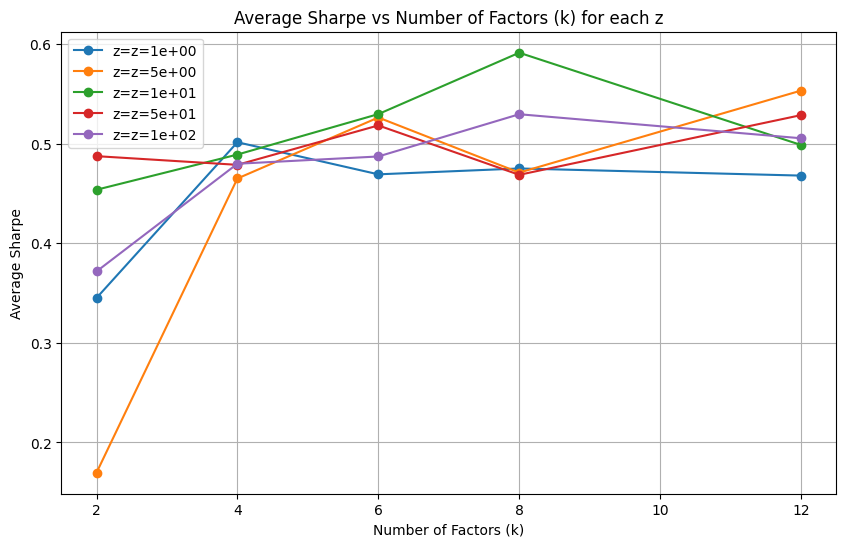

In [10]:
# lets plot sharpe vs k for each z, with one curve per z
plt.figure(figsize=(10, 6))
for z in Z_VALUES[1:]:
    z_key = _z_label(z)
    slice_df = results_rff_df_kz_grid.xs(z_key, level="z")["avg_sharpe"].unstack("P")
    if 4000 in slice_df.columns:
        series = slice_df[4000].sort_index()  # k on index
        series_interp = series.interpolate(method="index", limit_direction="both")
        plt.plot(series_interp.index, series_interp.values, marker="o", label=f"z={z_key}")
plt.title("Average Sharpe vs Number of Factors (k) for each z")
plt.xlabel("Number of Factors (k)")
plt.ylabel("Average Sharpe")
plt.grid()
plt.legend()
plt.show()

In [16]:
df_trunc_extended[char_feats_reduced] 
# get all  permnos list in the dataset, its just a few lets print all as a list
permnos = df_trunc_extended.index.get_level_values("permno").unique().tolist()
print(permnos)

[10026, 10028, 10032, 10044, 10104, 10107, 10145, 10158, 10180, 10182, 10200, 10220, 10253, 10302, 10318, 10363, 10382, 10397, 10421, 10501]


In [17]:
# lets see the names of these stocks from wrds queries
# lets get the stock names for these permnos from wrds, and print them as a list
import wrds
db = wrds.Connection()
permnos_str = ",".join(str(p) for p in permnos)
query = f"SELECT permno, comnam FROM crsp.stocknames WHERE permno IN ({permnos_str})"
stock_names = db.raw_sql(query)
print(stock_names)


WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
    permno                     comnam
0    10026     J & J SNACK FOODS CORP
1    10026     J & J SNACK FOODS CORP
2    10028          CANYON STATE CORP
3    10028  AMERICAN PACIFIC MINT INC
4    10028  AMERICAN PACIFIC MINT INC
..     ...                        ...
83   10382       ASTEC INDUSTRIES INC
84   10397     WERNER ENTERPRISES INC
85   10421                SKYWEST INC
86   10421                SKYWEST INC
87   10501     AMERICAN WOODMARK CORP

[88 rows x 2 columns]


In [25]:
print(stock_names.comnam.unique())
print(len(stock_names.comnam.unique()))

<StringArray>
[          'J & J SNACK FOODS CORP',                'CANYON STATE CORP',
        'AMERICAN PACIFIC MINT INC', 'DALLAS GOLD & SILVER EXCHANGE IN',
            'D G S E COMPANIES INC',                      'ENVELA CORP',
                      'PLEXUS CORP', 'ROCKY MOUNTAIN CHOCOLATE FAC INC',
  'ROCKY MOUNTAIN CHOC FAC INC NEW',              'ORACLE SYSTEMS CORP',
                      'ORACLE CORP',                   'MICROSOFT CORP',
       'ALLIED CHEMICAL & DYE CORP',             'ALLIED CHEMICAL CORP',
                      'ALLIED CORP',                'ALLIED SIGNAL INC',
      'HONEYWELL INTERNATIONAL INC',                     'AMERESCO INC',
                        'AKORN INC',                   'TECH DATA CORP',
                    'REPLIGEN CORP',          'BABCOCK & WILCOX CO NEW',
           'B W X TECHNOLOGIES INC',            'THOROUGHBREDS USA INC',
      'NEW SKY COMMMUNICATIONS INC',    'DOCUMENT SECURITY SYSTEMS INC',
                        'D S S INC', 